# DBSCAN sobre el dataset de diabetes limpio — `diabetic_clean.csv`

**Qué hace DBSCAN.** Para cada punto cuenta cuántos vecinos tiene dentro de un radio `eps` (incluyéndose a sí mismo).
- Si tiene al menos `min_samples` vecinos, es un **punto núcleo**.
- Los núcleos que están a distancia ≤ `eps` entre sí se encadenan y forman un **cluster** (una zona densa conectada).
- Un punto que no es núcleo pero está a ≤ `eps` de algún núcleo es **frontera**: se une al cluster, pero no lo expande.
- Todo lo demás es **ruido** (etiqueta `-1`).

No hay que fijar el número de clusters: sale de la densidad. A cambio, el resultado depende totalmente de la **escala** (`eps` en unidades de las features estandarizadas) y de cuántos vecinos exigimos (`min_samples`).

**Qué esperamos según el EDA del dataset limpio:**
- Hopkins ≈ 0.92, pero inflado porque las variables son **discretas** (grilla) y las de visitas previas son **cero-infladas** (87–93 % ceros).
- En PCA se ve **una sola nube con franjas**, sin grupos separados; se necesitan 7 de 10 componentes para el 80 % de la varianza.
- k-distancia (k = 20): percentiles 50/90/95/99 = 1.14 / 2.05 / 2.44 / 3.25, codo ≈ 2–3.
- Hipótesis de trabajo: con `eps` en el codo → **1 cluster gigante + ruido**; con `eps` más bajo → subgrupos con mucho ruido. Las “franjas” de las visitas previas (0 visitas vs ≥ 1) son candidatas a aparecer como clusters separados.

**Plan:** (2) preparar los datos → (3) elegir `eps`/`min_samples` con k-distancia y una grilla → (4) comparar con otros espacios (subconjunto de hospitalización y PCA) → (5) caracterizar la configuración final y cruzarla con `readmitted` → (6) analizar el ruido → (7) asignar el resto de filas → (8) resumen de la primera versión → **(9) revisión crítica: ¿los clusters son reales?** (validación con DBCV, estabilidad, prueba del jitter y validación externa) → (10) conclusiones.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score

T0 = time.time()
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
# Busca la carpeta Data/ subiendo desde la carpeta actual (funciona desde la raíz del repo o desde EDA/ y Modelos/)
DATA = next(p / 'Data' for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Data').is_dir())

C = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
MUTED = '#898781'
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': MUTED, 'axes.labelcolor': '#52514e', 'xtick.color': '#52514e', 'ytick.color': '#52514e',
    'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.titleweight': 'bold', 'axes.titlesize': 11, 'font.size': 9, 'axes.prop_cycle': plt.cycler(color=C),
})
OTROS = '#c9c8c2'          # gris claro para clusters agrupados como "otros" (el ruido va siempre en MUTED)
TARGET_ORDER = ['<30', '>30', 'NO']
TARGET_COLORS = dict(zip(TARGET_ORDER, C[:3]))
SEED, N_SAMPLE = 42, 20_000

## 2. Preparación de los datos

Usamos las 10 features numéricas candidatas del EDA (`FEAT`). Las visitas previas entran en su versión `log1p` (así lo recomendó el EDA). `patient_nbr` es un ID y **no** se usa.

- **Estandarización:** DBSCAN usa distancias euclidianas, así que todas las variables deben estar en la misma escala. `StandardScaler` deja cada una con media 0 y desviación 1; entonces `eps = 1` significa “una desviación estándar” de distancia.
- **Muestra:** DBSCAN necesita buscar vecinos de cada punto; con `eps` grande cada punto tiene miles de vecinos y el costo (tiempo y RAM) crece mucho. Trabajamos con una **muestra aleatoria de 20 000 filas** (`random_state=42`, ≈ 29 % del total), que es suficiente para ver la estructura de densidad. Al final (sección 7) asignamos las filas restantes a los clusters encontrados.
- El `StandardScaler` se ajusta con **todas** las filas (es barato) para que la muestra y el resto estén en la misma escala.

In [2]:
d = pd.read_csv(DATA / 'diabetic_clean.csv')
FEAT = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses',
        'number_outpatient_log', 'number_emergency_log', 'number_inpatient_log', 'age_num', 'n_meds_activos']
HOSP = ['time_in_hospital', 'num_medications', 'num_lab_procedures', 'num_procedures', 'number_diagnoses']

scaler = StandardScaler().fit(d[FEAT])
Z_all = scaler.transform(d[FEAT])                     # todas las filas, estandarizadas

idx = d.sample(N_SAMPLE, random_state=SEED).index.to_numpy()
s = d.loc[idx].reset_index(drop=True)                  # muestra (variables originales)
X = Z_all[idx]                                         # muestra estandarizada

print('Dataset completo:', d.shape, '| muestra:', X.shape)
comp = pd.DataFrame({'completo (%)': d['readmitted'].value_counts(normalize=True) * 100,
                     'muestra (%)': s['readmitted'].value_counts(normalize=True) * 100}).loc[TARGET_ORDER].round(1)
display(comp)

Dataset completo: (69987, 39) | muestra: (20000, 10)


,completo (%),muestra (%)
readmitted,,
<30,9.0,9.0
>30,31.8,31.1
NO,59.3,59.8


La muestra reproduce la distribución de `readmitted` del dataset completo, así que es representativa.

### ¿Hace falta *jitter*?
El EDA vio que los datos caen en una **grilla** (variables enteras). Si muchas filas fueran idénticas, un montón de puntos repetidos podría convertirse en núcleo “artificialmente”. Revisamos cuántas filas repetidas hay y qué tan grande es el paso mínimo de cada variable en unidades estandarizadas:

In [3]:
paso = {}
for j, f in enumerate(FEAT):
    u = np.unique(Z_all[:, j])
    paso[f] = np.diff(u).min()
tabla_paso = pd.DataFrame({'valores distintos': d[FEAT].nunique(), 'paso mínimo (en desv. estándar)': pd.Series(paso).round(3),
                           '% en el valor más frecuente': (d[FEAT].apply(lambda c: c.value_counts(normalize=True).iloc[0]) * 100).round(1)})
display(tabla_paso)
print(f'Filas repetidas (idénticas en las 10 features) en la muestra: {pd.DataFrame(X).duplicated().mean()*100:.1f}%')

,valores distintos,paso mínimo (en desv. estándar),% en el valor más frecuente
time_in_hospital,14,0.341,17.9
num_lab_procedures,116,0.050,3.2
num_procedures,7,0.569,44.1
num_medications,75,0.121,6.1
number_diagnoses,16,0.500,43.9
number_outpatient_log,33,0.072,87.0
number_emergency_log,18,0.380,92.7
number_inpatient_log,13,0.270,88.3
age_num,10,0.626,25.4
n_meds_activos,7,1.061,44.5


Filas repetidas (idénticas en las 10 features) en la muestra: 0.3%


- Solo el 0.3 % de las filas de la muestra (≈ 1 % en el dataset completo, según el EDA) son copias exactas: los empates no dominan el conteo de vecinos, así que **no aplicamos jitter en el análisis principal** (así los resultados se interpretan sobre los datos reales).
- Lo importante es otra cosa: las variables de visitas previas tienen un **salto grande** entre 0 y 1 visita (en unidades estandarizadas, más de 1 desviación) y concentran casi todo en el cero. Eso crea “capas” separadas en el espacio que DBSCAN puede detectar como clusters.
- En la sección 7 comprobamos que agregar un jitter pequeño (desv. 0.05) no cambia el resultado.

## 3. Elección de parámetros

### 3.1 Gráfico k-distancia
Para cada punto calculamos la distancia a su vecino número `m` (contando al propio punto, igual que DBSCAN cuenta `min_samples`). Si ordenamos esas distancias, la curva indica qué `eps` haría núcleo a qué fracción de los puntos: con `eps` = percentil p, aproximadamente p % de los puntos serían núcleo.

La regla práctica es `min_samples ≈ 2 × dimensión = 20`; también miramos 10 y 40. El codo **orienta**, no demuestra cuál es el `eps` óptimo.

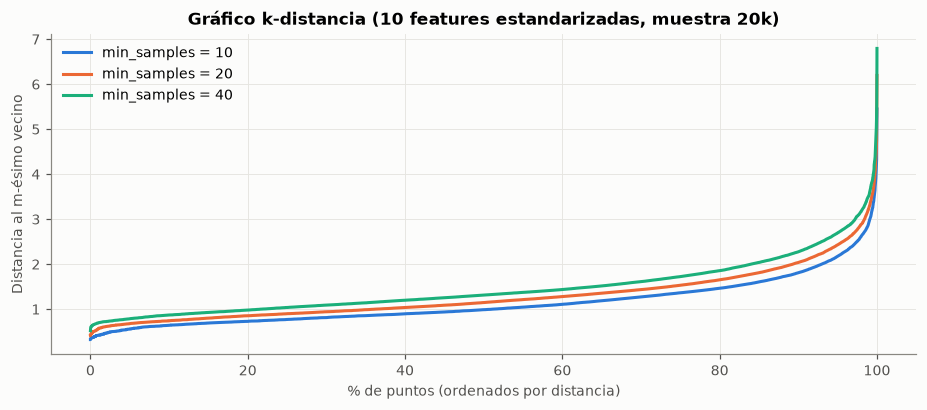

,p25,p50,p75,p90,p95,p99
m = 10,0.77,0.99,1.37,1.81,2.18,2.95
m = 20,0.90,1.15,1.53,2.04,2.43,3.26
m = 40,1.04,1.31,1.73,2.28,2.70,3.54


In [4]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
kdist_rows = []
for m, col in zip([10, 20, 40], C):
    dist = NearestNeighbors(n_neighbors=m).fit(X).kneighbors(X)[0][:, m - 1]   # columna m-1 = m-ésimo vecino incluyendo al propio punto
    kd = np.sort(dist)
    ax.plot(np.linspace(0, 100, len(kd)), kd, color=col, linewidth=2, label=f'min_samples = {m}')
    kdist_rows.append(pd.Series(np.percentile(kd, [25, 50, 75, 90, 95, 99]), index=['p25', 'p50', 'p75', 'p90', 'p95', 'p99'], name=f'm = {m}'))
ax.set_xlabel('% de puntos (ordenados por distancia)')
ax.set_ylabel('Distancia al m-ésimo vecino')
ax.set_title('Gráfico k-distancia (10 features estandarizadas, muestra 20k)')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
display(pd.DataFrame(kdist_rows).round(2))

La curva sube suave y solo se dispara en el último 5–10 %. No hay un “escalón” claro que separe zonas densas de zonas vacías: esa es la primera señal de que la estructura de densidad es débil. Por eso, en vez de fiarnos de un único codo, recorremos una **grilla** de valores de `eps` alrededor de la curva (de ≈ p5 a ≈ p99) y de `min_samples`.

### 3.2 Grilla `eps × min_samples`
Para cada combinación registramos:
- **n° de clusters** (todos, y solo los que tienen ≥ 1 % de la muestra, porque DBSCAN suele generar muchos grupitos de 10–30 puntos);
- **% de ruido** y **% de la muestra en el cluster más grande**;
- **silhouette** (−1 a 1; mayor = clusters más compactos y separados) calculado **sin el ruido** sobre una submuestra de 10 000 puntos;
- **Davies-Bouldin** (≥ 0; menor = mejor).

Ojo: ambas métricas ignoran el ruido, así que una configuración que tira el 90 % de los datos a ruido puede tener un silhouette “bonito”. Hay que leerlas junto con el % de ruido.

In [5]:
def evaluar(Xsp, eps, ms, sil_n=10_000):
    """Ajusta DBSCAN y devuelve (métricas, etiquetas)."""
    t = time.time()
    lab = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1).fit_predict(Xsp)
    m = lab != -1
    k = len(np.unique(lab[m]))
    sizes = np.bincount(lab[m]) if k else np.array([0])
    sil = db = np.nan
    if k >= 2:
        sil = silhouette_score(Xsp[m], lab[m], sample_size=min(sil_n, m.sum()), random_state=SEED)
        db = davies_bouldin_score(Xsp[m], lab[m])
    res = dict(eps=eps, min_samples=ms, n_clusters=k, n_clusters_1pct=int((sizes >= 0.01 * len(lab)).sum()),
               pct_ruido=100 * (~m).mean(), pct_mayor=100 * sizes.max() / len(lab),
               silhouette=sil, davies_bouldin=db, seg=time.time() - t)
    return res, lab

EPS_GRID = [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
MS_GRID = [10, 20, 40]
filas, LABELS = [], {}
for ms in MS_GRID:
    for eps in EPS_GRID:
        r, lab = evaluar(X, eps, ms)
        filas.append(r); LABELS[(eps, ms)] = lab
grid = pd.DataFrame(filas)
print(f'Tiempo total de la grilla: {grid.seg.sum():.0f} s')
display(grid.drop(columns='seg').round(3))

Tiempo total de la grilla: 99 s


,eps,min_samples,n_clusters,n_clusters_1pct,pct_ruido,pct_mayor,silhouette,davies_bouldin
0,0.50,10,26,1,94.395,1.065,0.095,1.479
1,0.75,10,23,4,63.355,18.705,-0.133,1.370
2,1.00,10,19,5,35.235,28.395,-0.060,2.036
3,1.25,10,9,4,20.295,70.140,0.052,1.551
4,1.50,10,10,4,10.690,72.860,0.143,1.740
5,1.75,10,8,4,5.925,73.400,0.173,1.853
6,2.00,10,6,3,3.170,82.340,0.198,1.711
7,2.50,10,2,2,0.880,92.450,0.269,1.681
8,3.00,10,2,2,0.255,92.605,0.278,1.673
9,0.50,20,6,0,98.525,0.500,0.324,1.247


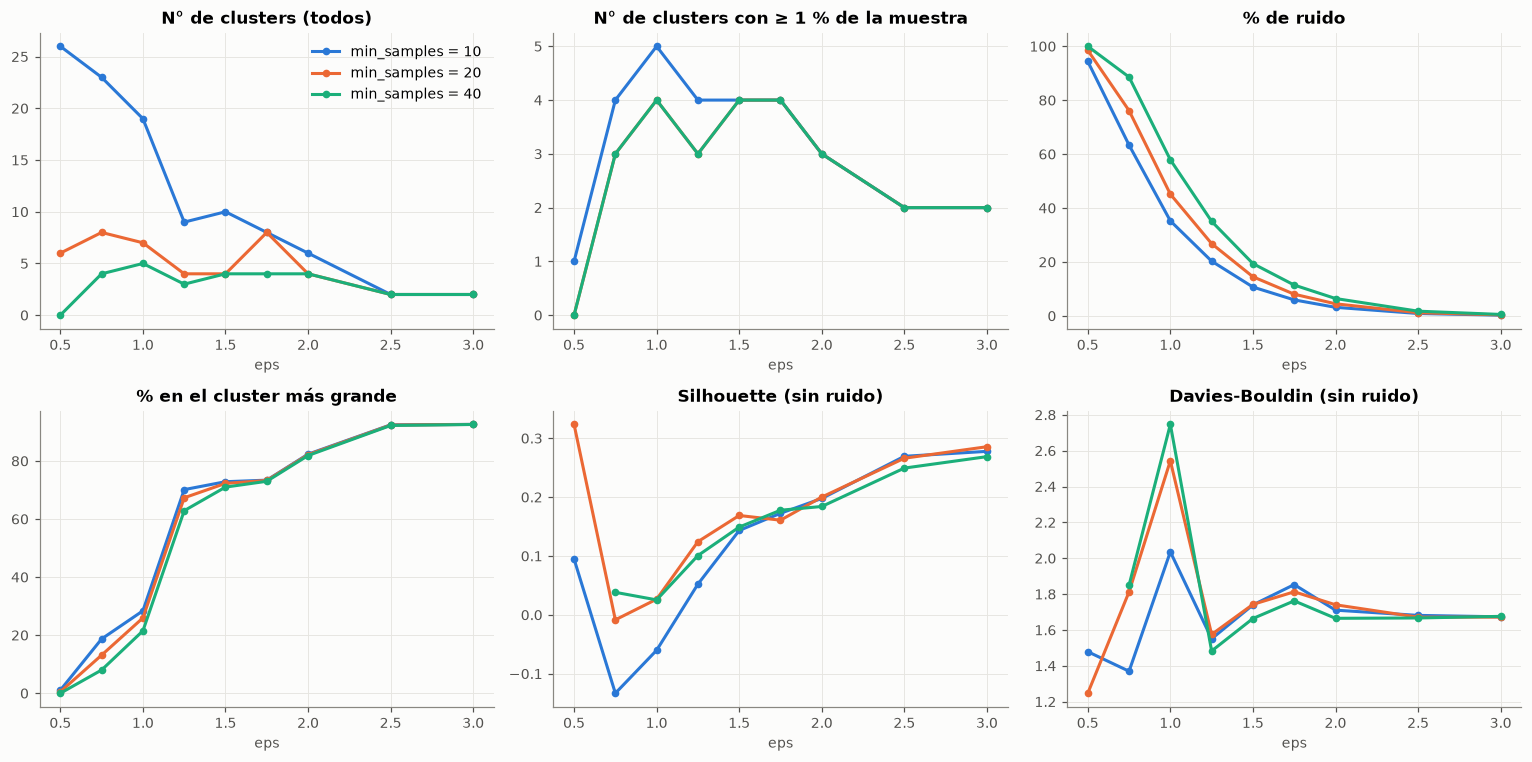

In [6]:
metricas = [('n_clusters', 'N° de clusters (todos)'), ('n_clusters_1pct', 'N° de clusters con ≥ 1 % de la muestra'),
            ('pct_ruido', '% de ruido'), ('pct_mayor', '% en el cluster más grande'),
            ('silhouette', 'Silhouette (sin ruido)'), ('davies_bouldin', 'Davies-Bouldin (sin ruido)')]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (col, titulo) in zip(axes.ravel(), metricas):
    for ms, c in zip(MS_GRID, C):
        g = grid[grid.min_samples == ms]
        ax.plot(g.eps, g[col], marker='o', markersize=4, linewidth=2, color=c, label=f'min_samples = {ms}')
    ax.set_title(titulo); ax.set_xlabel('eps')
axes[0, 0].legend(frameon=False)
plt.tight_layout(); plt.show()

**Cómo leer la grilla** (los números exactos están en la tabla de arriba):
- Con `eps` pequeño (0.5–0.75) el 63–100 % es ruido: en 10 dimensiones los puntos están demasiado dispersos para tener 10–40 vecinos tan cerca. Los “clusters” que aparecen son grupitos de puntos casi idénticos (con `min_samples = 10` salen hasta 26 clusters, casi todos de < 1 %).
- Con `eps` = 1.0 hay una zona inestable: 35–58 % de ruido, silhouette ≈ 0 o negativo y Davies-Bouldin máximo (2.0–2.7): los clusters se tocan.
- Con `eps` = 1.25 aparece el **cluster dominante** (63–70 %) y la estructura se estabiliza en `eps` = 1.5–1.75: **4 clusters con ≥ 1 %** para los tres valores de `min_samples`, 6–19 % de ruido, silhouette 0.14–0.18, Davies-Bouldin ≈ 1.7–1.85.
- Con `eps` = 2.0 queda un cluster de ~82 % y 3 relevantes; con `eps` ≥ 2.5 quedan solo 2 clusters (uno de ~92 %). El silhouette sube hasta 0.27–0.29, pero es engañoso: premia una partición casi trivial (un cluster enorme y uno pequeño) con < 2 % de ruido.
- `min_samples` cambia poco la historia a partir de `eps` ≈ 1.25: sobre todo desplaza el % de ruido (más exigente = más ruido). Con 10 aparecen además varios clusters minúsculos.

En la sección 5 veremos que esos clusters medianos **no** son grupos de “intensidad de hospitalización” sino las **capas de visitas previas** (0 visitas vs. ≥ 1 hospitalización, urgencia o consulta previa).

## 4. ¿Y en otros espacios de features?

Probamos dos alternativas recomendadas por el EDA:
1. **Subconjunto “intensidad de la hospitalización”** (5 variables: `time_in_hospital`, `num_medications`, `num_lab_procedures`, `num_procedures`, `number_diagnoses`), sin visitas previas, edad ni medicamentos activos. Es más interpretable: ¿hay tipos de hospitalización (cortas/livianas vs. largas/intensas)?
2. **Primeras 5 componentes PCA** de las 10 features estandarizadas (PC1 = intensidad, PC2 = visitas previas, PC3 = edad/diagnósticos). PCA quita ruido de las últimas direcciones y “suaviza” la grilla porque mezcla variables.

Como cada espacio tiene su propia escala, primero miramos la k-distancia (m = 20) de cada uno para elegir un rango de `eps` comparable.

Varianza explicada por 5 componentes: 65.9%


10 features (FEAT)         k-dist (m=20) p50/p90/p95/p99: [1.15 2.04 2.43 3.26]


Hospitalización (5 var.)   k-dist (m=20) p50/p90/p95/p99: [0.52 0.86 1.01 1.4 ]


PCA (5 comp.)              k-dist (m=20) p50/p90/p95/p99: [0.57 1.12 1.33 1.9 ]


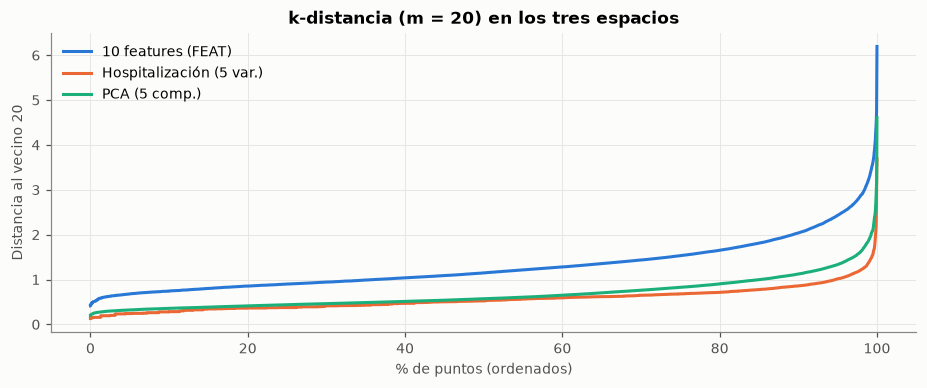

In [7]:
Xh = StandardScaler().fit_transform(d[HOSP])[idx]
pca5 = PCA(n_components=5, random_state=SEED).fit(Z_all)
Xp = pca5.transform(Z_all)[idx]
print(f'Varianza explicada por 5 componentes: {pca5.explained_variance_ratio_.sum()*100:.1f}%')

ESPACIOS = {'10 features (FEAT)': X, 'Hospitalización (5 var.)': Xh, 'PCA (5 comp.)': Xp}
fig, ax = plt.subplots(figsize=(8.5, 3.6))
for (nombre, Xsp), col in zip(ESPACIOS.items(), C):
    kd = np.sort(NearestNeighbors(n_neighbors=20).fit(Xsp).kneighbors(Xsp)[0][:, 19])
    ax.plot(np.linspace(0, 100, len(kd)), kd, color=col, linewidth=2, label=nombre)
    print(f'{nombre:26s} k-dist (m=20) p50/p90/p95/p99: {np.percentile(kd, [50, 90, 95, 99]).round(2)}')
ax.set_xlabel('% de puntos (ordenados)'); ax.set_ylabel('Distancia al vecino 20')
ax.set_title('k-distancia (m = 20) en los tres espacios'); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

In [8]:
EPS_OTROS = {'Hospitalización (5 var.)': [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.25],
             'PCA (5 comp.)': [0.3, 0.5, 0.6, 0.75, 0.9, 1.0, 1.25, 1.5]}
filas = []
for nombre, eps_list in EPS_OTROS.items():
    for ms in [10, 20]:
        for eps in eps_list:
            r, _ = evaluar(ESPACIOS[nombre], eps, ms)
            filas.append({'espacio': nombre, **r})
grid_otros = pd.DataFrame(filas)
display(grid_otros.drop(columns='seg').round(3))

,espacio,eps,min_samples,n_clusters,n_clusters_1pct,pct_ruido,pct_mayor,silhouette,davies_bouldin
0,Hospitalización (5 var.),0.30,10,98,7,65.915,3.385,-0.115,1.830
1,Hospitalización (5 var.),0.40,10,60,11,41.180,16.835,-0.136,1.773
2,Hospitalización (5 var.),0.50,10,26,5,25.480,40.960,-0.254,1.944
3,Hospitalización (5 var.),0.60,10,4,1,12.695,87.155,0.023,0.925
4,Hospitalización (5 var.),0.70,10,5,1,5.895,93.955,0.072,0.751
5,Hospitalización (5 var.),0.80,10,2,1,2.730,97.240,0.259,0.746
6,Hospitalización (5 var.),1.00,10,1,1,0.750,99.250,NaN,NaN
7,Hospitalización (5 var.),1.25,10,1,1,0.240,99.760,NaN,NaN
8,Hospitalización (5 var.),0.30,20,29,5,81.935,2.875,-0.015,2.028
9,Hospitalización (5 var.),0.40,20,20,8,57.865,15.530,-0.077,2.126


Para comparar espacios con escalas distintas usamos una gráfica que no depende de `eps`: cada punto es un valor de `eps` y lo ubicamos por **% de ruido** (eje x) y **% en el cluster más grande** (eje y), con `min_samples = 20`. Un espacio con grupos reales tendría una zona con **poco ruido y cluster mayor lejos del 100 %**.

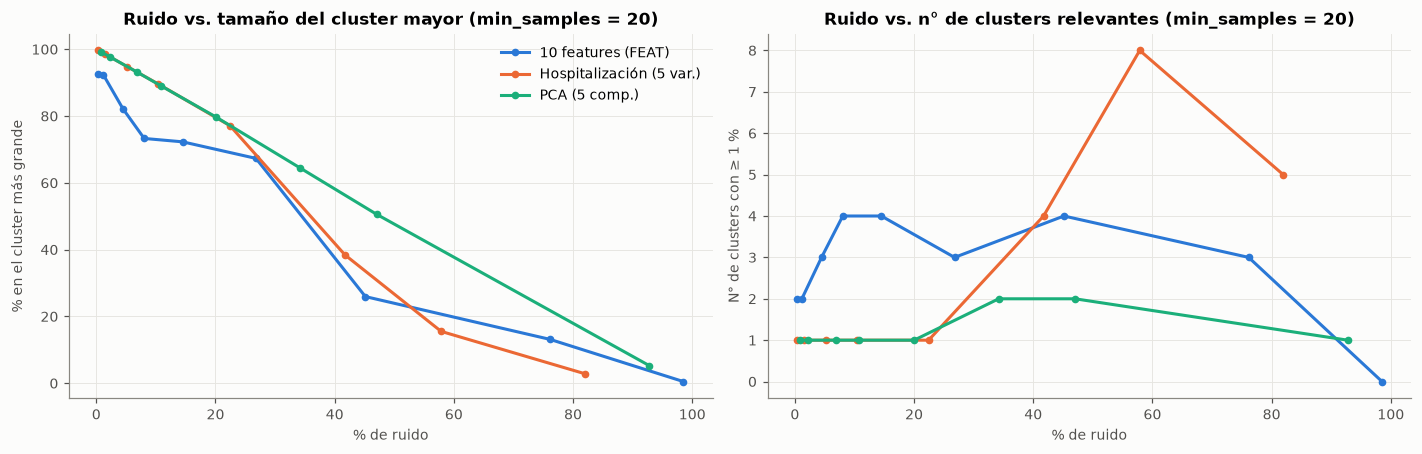

In [9]:
todo = pd.concat([grid.assign(espacio='10 features (FEAT)'), grid_otros])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for (nombre, g), col in zip(todo[todo.min_samples == 20].groupby('espacio', sort=False), C):
    g = g.sort_values('eps')
    axes[0].plot(g.pct_ruido, g.pct_mayor, marker='o', markersize=4, linewidth=2, color=col, label=nombre)
    axes[1].plot(g.pct_ruido, g.n_clusters_1pct, marker='o', markersize=4, linewidth=2, color=col, label=nombre)
axes[0].set_xlabel('% de ruido'); axes[0].set_ylabel('% en el cluster más grande')
axes[0].set_title('Ruido vs. tamaño del cluster mayor (min_samples = 20)')
axes[1].set_xlabel('% de ruido'); axes[1].set_ylabel('N° de clusters con ≥ 1 %')
axes[1].set_title('Ruido vs. n° de clusters relevantes (min_samples = 20)')
axes[0].legend(frameon=False)
plt.tight_layout(); plt.show()

**Lectura:**
- **Hospitalización (5 var.)** y **PCA (5 comp.)**: cuando el ruido baja de ~20–25 %, todo cae en **un solo cluster relevante** (77–99 % de la muestra). Para tener más de un cluster relevante hay que aceptar 25–80 % de ruido, y aun así el silhouette es ≈ 0 o negativo (−0.30 a 0.09: grupos que se tocan). Es decir: **la intensidad de la hospitalización es un continuo, no hay “tipos” de hospitalización separados por zonas de baja densidad.**
- En PCA, las componentes mezclan las variables de visitas con las demás y la separación entre capas se diluye: también converge a un único cluster.
- Solo en el **espacio completo de 10 features** aparecen varios clusters relevantes con ruido moderado (10–15 %). Por eso elegimos ese espacio para la configuración final, sabiendo (lo veremos enseguida) que la separación viene de las variables de visitas previas.

## 5. Configuración final

Criterios para elegir (fijados antes de mirar los perfiles):
1. más de un cluster con ≥ 1 % de la muestra (no solo el cluster gigante);
2. ruido acotado (idealmente ≤ 15 %);
3. silhouette positivo y de los mejores dentro de las opciones que cumplen 1–2;
4. estable: que no cambie mucho al mover `eps` un paso o cambiar `min_samples`.

Con la grilla, **`eps = 1.5` y `min_samples = 20`** (el valor de la regla 2 × dimensión) cumple los cuatro: 4 clusters, todos ≥ 1 %, 14.5 % de ruido, silhouette 0.17, y con `eps` = 1.5–1.75 y `min_samples` = 10, 20 o 40 se obtienen siempre 4 clusters relevantes. Alternativas descartadas:
- `eps = 1.75` es igual de válida (mismos 4 grupos, 8 % de ruido) pero agrega 4 clusters minúsculos (< 1 %) que complican la lectura.
- `eps = 2.0` tiene menos ruido (4.5 %) y silhouette 0.20, pero el cluster de consultas ambulatorias se fusiona con el grande (sección 7).
- `eps ≥ 2.5` tiene el mejor silhouette, pero es casi un solo cluster.
- `min_samples = 10` produce clusters extra de pocos puntos.

In [10]:
EPS_F, MS_F = 1.5, 20
modelo = DBSCAN(eps=EPS_F, min_samples=MS_F, n_jobs=-1).fit(X)
lab_raw = modelo.labels_

# Renumerar clusters por tamaño (0 = el más grande); el ruido sigue siendo -1
orden = pd.Series(lab_raw[lab_raw != -1]).value_counts().index
mapa = {old: new for new, old in enumerate(orden)}
lab = np.array([mapa.get(l, -1) for l in lab_raw])

s['cluster'] = lab
s['prev_hosp'] = s['number_inpatient'] > 0
s['prev_urg'] = s['number_emergency'] > 0
s['prev_amb'] = s['number_outpatient'] > 0

# Nombre automático según qué tipo de visita previa predomina en el cluster
def nombre_cluster(g):
    partes = [n for col, n in [('prev_hosp', 'hosp. previa'), ('prev_urg', 'urgencias previas'), ('prev_amb', 'consulta amb. previa')]
              if g[col].mean() > 0.5]
    return ' + '.join(partes).capitalize() if partes else 'Sin visitas previas'
NOMBRES = {k: f'C{k} · {nombre_cluster(g)}' for k, g in s[s.cluster >= 0].groupby('cluster')}
NOMBRES[-1] = 'Ruido (-1)'

# Colores: hasta 8 clusters en el orden de C; si hubiera más, se agrupan como "Otros" en gris claro
k_final = len(orden)
COLOR_CL = {k: (C[k] if k < 8 else OTROS) for k in range(k_final)}
COLOR_CL[-1] = MUTED
if k_final > 8:
    for k in range(8, k_final): NOMBRES[k] = 'Otros (clusters pequeños)'

m = lab != -1
sil_f = silhouette_score(X[m], lab[m], sample_size=10_000, random_state=SEED)
db_f = davies_bouldin_score(X[m], lab[m])
print(f'eps = {EPS_F}, min_samples = {MS_F}')
print(f'Clusters: {k_final} | ruido: {(~m).mean()*100:.1f}% | núcleos: {len(modelo.core_sample_indices_)} '
      f'({len(modelo.core_sample_indices_)/len(X)*100:.1f}%) | silhouette: {sil_f:.3f} | Davies-Bouldin: {db_f:.2f}')

tam = s['cluster'].map(NOMBRES).value_counts().rename('n').to_frame()
tam['%'] = (tam['n'] / len(s) * 100).round(1)
display(tam)

eps = 1.5, min_samples = 20
Clusters: 4 | ruido: 14.5% | núcleos: 14700 (73.5%) | silhouette: 0.169 | Davies-Bouldin: 1.74


,n,%
cluster,,
C0 · Sin visitas previas,14456,72.3
Ruido (-1),2901,14.5
C1 · Consulta amb. previa,1231,6.2
C2 · Hosp. previa,1011,5.1
C3 · Urgencias previas,401,2.0


### 5.1 Perfil de cada cluster
Medias de las variables **originales** (sin escalar) por cluster. Para las visitas previas mostramos el conteo original y el % de pacientes con al menos una.

In [11]:
PERFIL = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses',
          'number_outpatient', 'number_emergency', 'number_inpatient', 'age_num', 'n_meds_activos']
s['grupo'] = s['cluster'].map(NOMBRES)
orden_grupos = [NOMBRES[k] for k in range(min(k_final, 8))] + (['Otros (clusters pequeños)'] if k_final > 8 else []) + ['Ruido (-1)']
perfil = s.groupby('grupo')[PERFIL].mean().loc[orden_grupos]
perfil.loc['Total muestra'] = s[PERFIL].mean()
flags = (s.groupby('grupo')[['prev_hosp', 'prev_urg', 'prev_amb']].mean() * 100).loc[orden_grupos]
flags.loc['Total muestra'] = s[['prev_hosp', 'prev_urg', 'prev_amb']].mean() * 100
flags.columns = ['% con hosp. previa', '% con urgencias previas', '% con consulta amb. previa']
tabla_perfil = pd.concat([perfil.round(2), flags.round(1)], axis=1)
tabla_perfil.insert(0, 'n', s['grupo'].value_counts().reindex(tabla_perfil.index).fillna(len(s)).astype(int))
display(tabla_perfil)

,n,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,number_outpatient,number_emergency,number_inpatient,age_num,n_meds_activos,% con hosp. previa,% con urgencias previas,% con consulta amb. previa
grupo,,,,,,,,,,,,,,
C0 · Sin visitas previas,14456,4.14,42.37,1.43,15.10,7.07,0.00,0.00,0.00,65.22,1.17,0.0,0.0,0.0
C1 · Consulta amb. previa,1231,3.30,37.21,0.81,14.31,7.74,1.63,0.00,0.00,68.94,1.15,0.0,0.0,100.0
C2 · Hosp. previa,1011,3.98,47.15,0.83,14.61,7.67,0.00,0.00,1.19,69.00,1.12,100.0,0.0,0.0
C3 · Urgencias previas,401,3.34,42.81,0.60,13.29,7.80,0.00,1.00,0.00,65.92,1.17,0.0,100.0,0.0
Ruido (-1),2901,5.48,45.31,1.97,19.49,7.50,1.26,0.56,0.84,63.05,1.37,47.0,36.8,49.9
Total muestra,20000,4.26,42.73,1.43,15.63,7.22,0.28,0.10,0.18,65.34,1.20,11.9,7.3,13.4


Para comparar variables con escalas distintas, el heatmap muestra la media de cada cluster **en desviaciones estándar respecto a la media global** (z-score de la media, usando las 10 features del modelo). Rojo = el cluster está por encima del promedio; azul = por debajo.

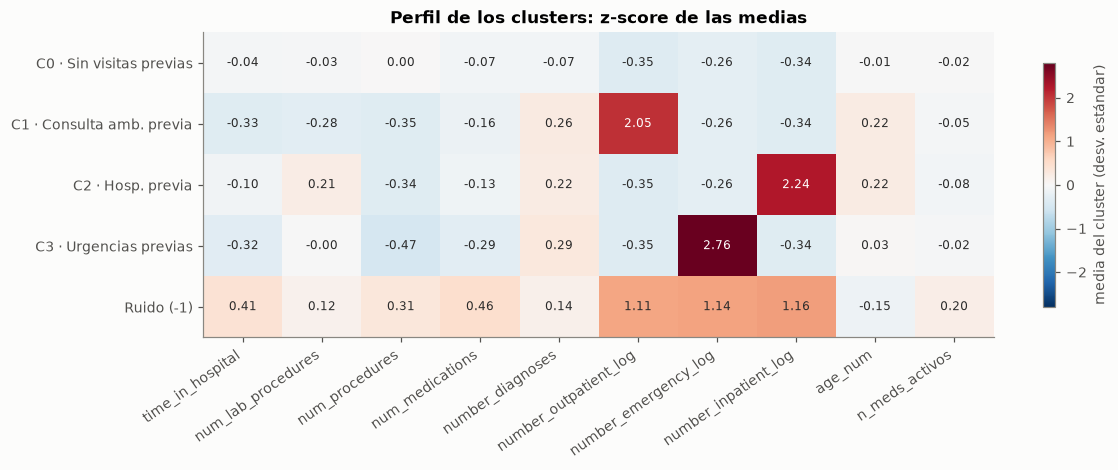

In [12]:
Zs = pd.DataFrame(X, columns=FEAT)
Zs['grupo'] = s['grupo']
zmedias = Zs.groupby('grupo')[FEAT].mean().loc[orden_grupos]
lim = np.ceil(np.abs(zmedias.values).max() * 10) / 10
fig, ax = plt.subplots(figsize=(11, 0.55 * len(zmedias) + 1.6))
im = ax.imshow(zmedias.values, cmap='RdBu_r', vmin=-lim, vmax=lim, aspect='auto')
ax.set_xticks(range(len(FEAT))); ax.set_xticklabels(FEAT, rotation=35, ha='right')
ax.set_yticks(range(len(zmedias))); ax.set_yticklabels(zmedias.index)
for i in range(zmedias.shape[0]):
    for j in range(zmedias.shape[1]):
        v = zmedias.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(v) > lim * 0.6 else '#2b2b2b')
ax.grid(False)
fig.colorbar(im, ax=ax, label='media del cluster (desv. estándar)', shrink=0.8)
ax.set_title('Perfil de los clusters: z-score de las medias')
plt.tight_layout(); plt.show()

**Lectura del perfil:** los clusters **no** se diferencian por intensidad de la hospitalización (días, laboratorios, medicamentos: todas las diferencias son < 0.5 desviaciones). Lo que los separa es **exclusivamente el tipo de visita previa**, con pureza del 100 %:
- **C0 · Sin visitas previas** (72 %): 0 hospitalizaciones, 0 urgencias y 0 consultas en el año anterior. Es el paciente “típico” del dataset.
- **C1 · Consulta amb. previa** (6 %): todos tienen ≥ 1 consulta ambulatoria (media 1.6) y ninguna otra visita; estancias algo más cortas (3.3 días) y menos procedimientos.
- **C2 · Hosp. previa** (5 %): todos con ≥ 1 hospitalización previa (media 1.2), sin urgencias ni consultas; algo más de laboratorios (47) y mayores (69 años).
- **C3 · Urgencias previas** (2 %): todos con ≥ 1 visita a urgencias (media 1.0) y nada más.
- **Ruido** (14.5 %): hospitalizaciones más intensas (5.5 días, 19.5 medicamentos, 2 procedimientos) y, sobre todo, **combinaciones y repeticiones** de visitas previas (ver sección 6).

¿Por qué pasa esto? Pasar de 0 a 1 visita previa es un salto de ≈ 2–3 desviaciones en la variable `_log` correspondiente (porque casi todos tienen 0), mucho mayor que los pasos de las otras variables. DBSCAN encuentra zonas densas separadas por esos huecos: cada “capa” (0 visitas, exactamente un tipo de visita) es una zona densa; los pacientes con varias visitas o combinaciones quedan en zonas poco pobladas → ruido.

### 5.2 ¿Cómo se ven los clusters?
- **Izquierda:** proyección PCA 2D (PC1 = intensidad de la hospitalización, PC2 = visitas previas). El ruido va en gris.
- **Centro y derecha:** las variables de visitas previas (`_log`). Como son discretas, se les suma un pequeño desplazamiento aleatorio **solo para dibujar** (para que los puntos no se tapen); el modelo no lo usó. Ojo: en el origen (0, 0) de estos paneles se superponen varios clusters (p. ej. “sin visitas” y “consulta amb. previa” tienen 0 hospitalizaciones y 0 urgencias); cada cluster se distingue en el panel donde aparece su propia variable.

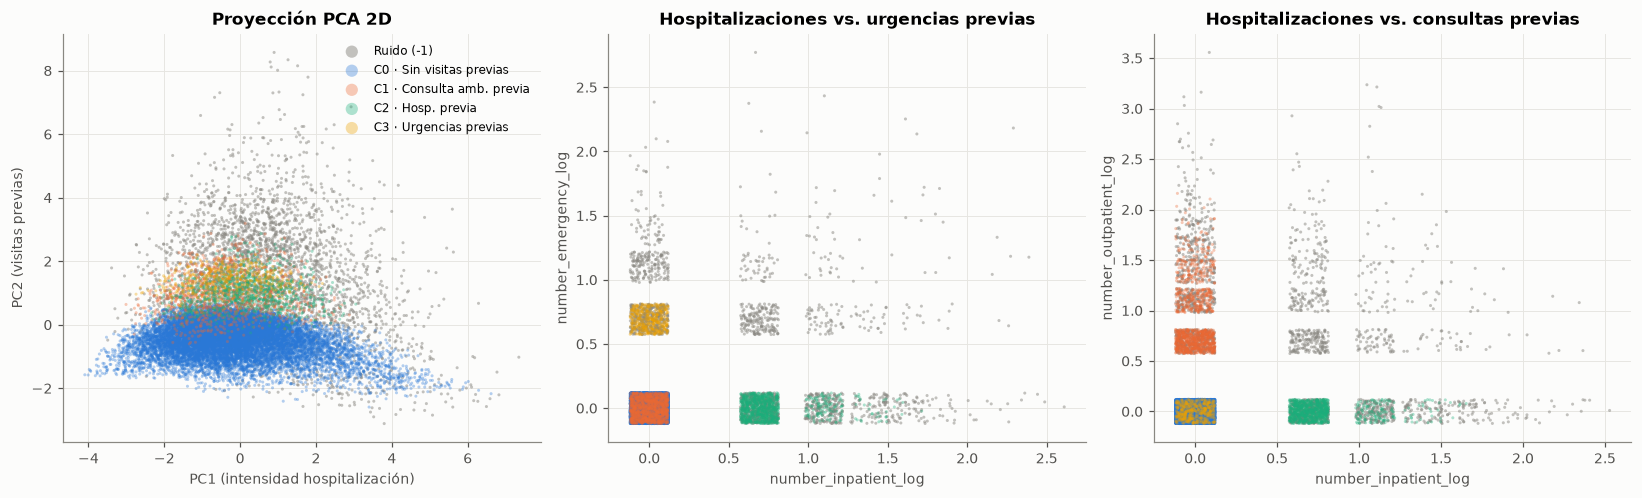

In [13]:
pca2 = PCA(n_components=2, random_state=SEED).fit(Z_all)
P = pca2.transform(X)
rj = np.random.default_rng(0)
jit = lambda v: v + rj.uniform(-0.12, 0.12, len(v))
paneles = [(P[:, 0], P[:, 1], 'PC1 (intensidad hospitalización)', 'PC2 (visitas previas)', 'Proyección PCA 2D'),
           (jit(s['number_inpatient_log'].values), jit(s['number_emergency_log'].values), 'number_inpatient_log', 'number_emergency_log', 'Hospitalizaciones vs. urgencias previas'),
           (jit(s['number_inpatient_log'].values), jit(s['number_outpatient_log'].values), 'number_inpatient_log', 'number_outpatient_log', 'Hospitalizaciones vs. consultas previas')]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (xv, yv, xl, yl, tit) in zip(axes, paneles):
    for g in ['Ruido (-1)'] + orden_grupos[:-1]:
        mk = (s['grupo'] == g).values
        col = MUTED if g == 'Ruido (-1)' else COLOR_CL[[k for k, n in NOMBRES.items() if n == g][0]]
        ax.scatter(xv[mk], yv[mk], s=4, alpha=0.35 if g != 'Ruido (-1)' else 0.5, color=col, edgecolors='none', label=g)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(tit)
axes[0].legend(markerscale=4, frameon=False, fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()

### 5.3 Cruce con `readmitted`
DBSCAN no vio la variable objetivo. Si los clusters tienen tasas de reingreso distintas, hay información útil; si no, los grupos son solo geométricos.

readmitted,n,% <30,% >30,% NO
grupo,,,,
C0 · Sin visitas previas,14456.0,7.9,27.5,64.6
C1 · Consulta amb. previa,1231.0,9.7,38.5,51.7
C2 · Hosp. previa,1011.0,13.5,43.9,42.6
C3 · Urgencias previas,401.0,8.0,39.2,52.9
Ruido (-1),2901.0,13.0,40.6,46.4
Total muestra,20000.0,9.0,31.1,59.8


Chi² (clusters sin ruido vs readmitted): 278.0, p = 4.2e-57, V de Cramér = 0.090


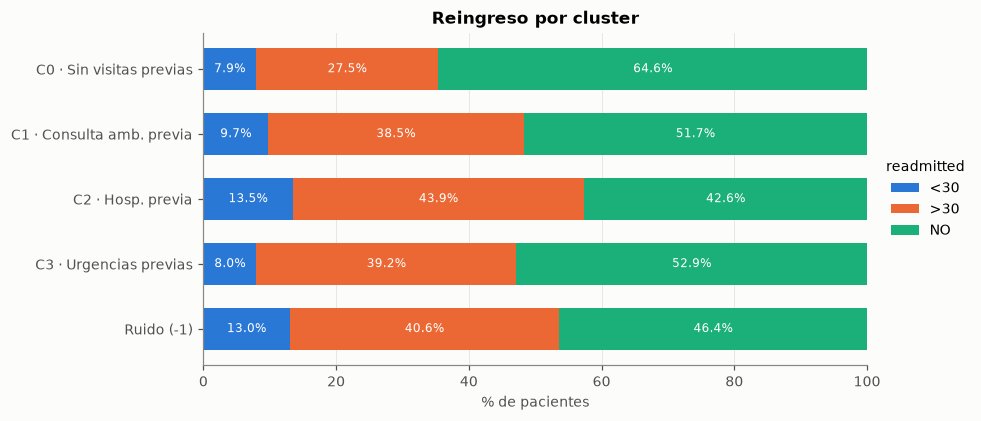

In [14]:
ct = pd.crosstab(s['grupo'], s['readmitted']).loc[orden_grupos, TARGET_ORDER]
pct = (ct.div(ct.sum(axis=1), axis=0) * 100)
tabla_r = pct.round(1).rename(columns=lambda c: f'% {c}')
tabla_r.insert(0, 'n', ct.sum(axis=1))
tabla_r.loc['Total muestra'] = [len(s)] + list((s['readmitted'].value_counts(normalize=True) * 100).loc[TARGET_ORDER].round(1))
display(tabla_r)
chi2, p, dof, _ = chi2_contingency(ct.loc[[g for g in orden_grupos if g != 'Ruido (-1)']])
n_ = ct.drop(index='Ruido (-1)').values.sum()
v = np.sqrt(chi2 / (n_ * (min(ct.shape) - 1)))
print(f'Chi² (clusters sin ruido vs readmitted): {chi2:.1f}, p = {p:.2g}, V de Cramér = {v:.3f}')

fig, ax = plt.subplots(figsize=(9, 0.5 * len(pct) + 1.4))
izq = np.zeros(len(pct))
for k in TARGET_ORDER:
    ax.barh(range(len(pct)), pct[k], left=izq, color=TARGET_COLORS[k], label=k, height=0.65)
    for i, (l, w) in enumerate(zip(izq, pct[k])):
        if w > 4: ax.text(l + w / 2, i, f'{w:.1f}%', ha='center', va='center', color='white', fontsize=8)
    izq += pct[k].values
ax.set_yticks(range(len(pct))); ax.set_yticklabels(pct.index); ax.invert_yaxis()
ax.set_xlabel('% de pacientes'); ax.set_xlim(0, 100); ax.grid(axis='y', visible=False)
ax.set_title('Reingreso por cluster'); ax.legend(title='readmitted', frameon=False, loc='center left', bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(); plt.show()

- En PCA 2D los clusters aparecen como **franjas horizontales en PC2** (el eje de visitas previas), no como nubes separadas en PC1: confirma que la intensidad de la hospitalización no separa a nadie.
- **Reingreso:** C0 (sin visitas previas) reingresa menos que el promedio (7.9 % `<30`, 27.5 % `>30`). C2 (hosp. previa) y el ruido son los grupos de mayor riesgo (13.5 % y 13.0 % `<30`; ~41–44 % `>30`). C1 y C3 están en el medio: similar `<30` al promedio, pero más `>30`.
- La asociación es estadísticamente significativa (χ², p ≈ 4·10⁻⁵⁷) pero **débil** (V de Cramér = 0.09): con 17 000 pacientes cualquier diferencia pequeña es “significativa”. Es la misma señal que ya mostraba el EDA para `number_inpatient`: DBSCAN la redescubre, no agrega información nueva.

### 5.4 Cruce con variables categóricas
Tipo de alta (`discharge_disposition_id`) y capítulo del diagnóstico principal (`diag_1`). Mostramos el % de cada categoría dentro de cada cluster (las categorías menos frecuentes se agrupan en “Otras”).

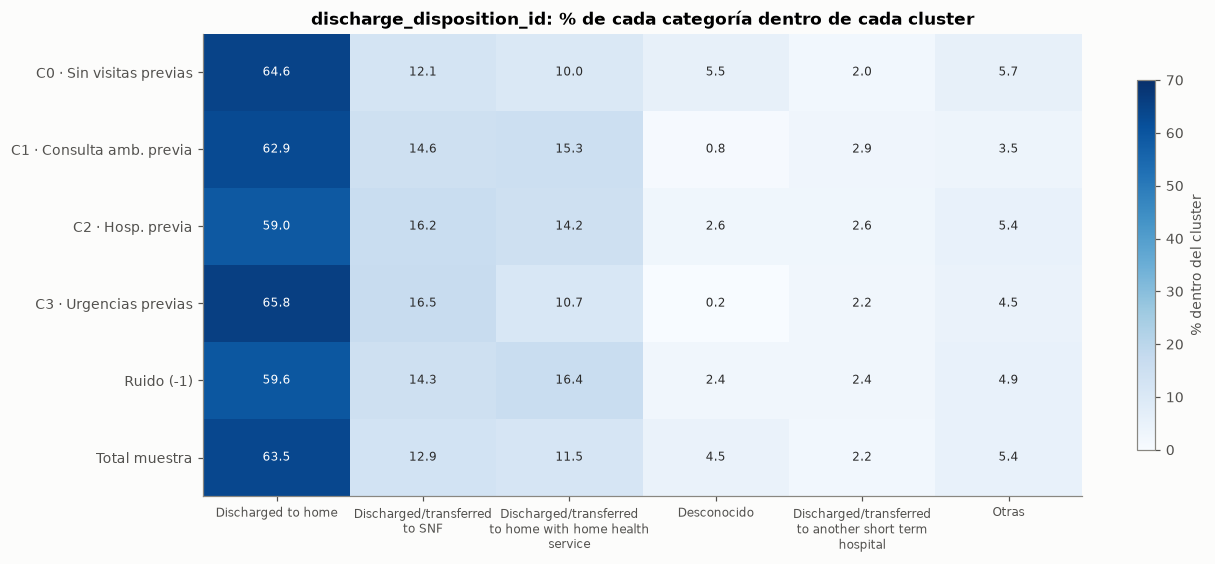

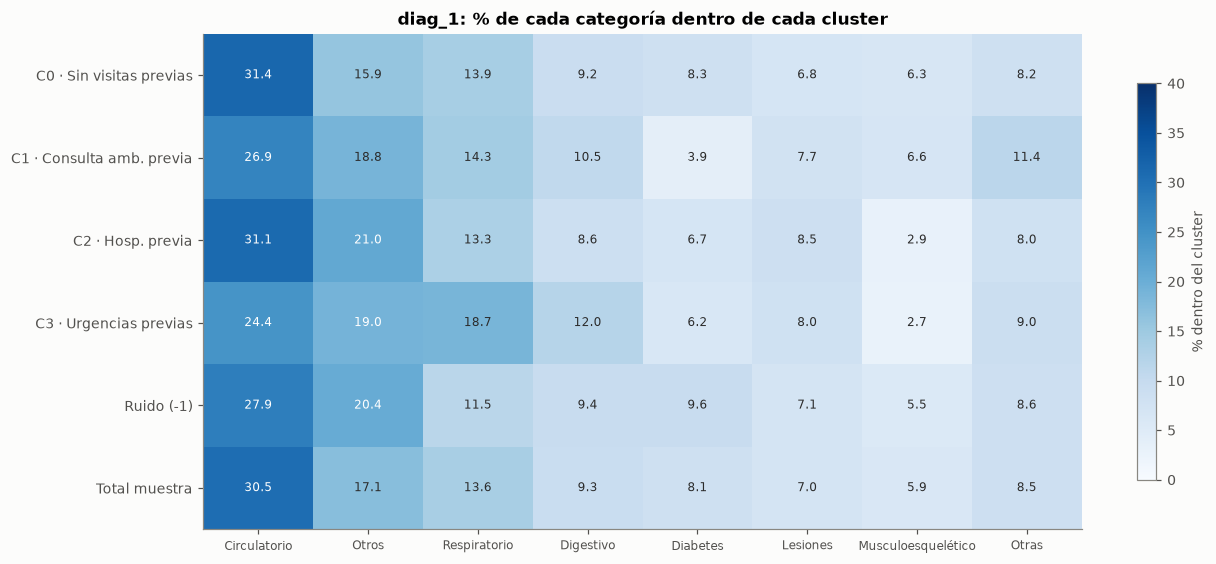

In [15]:
import textwrap

def cruce_cat(col, top=5):
    principales = s[col].value_counts().index[:top]
    v = s[col].where(s[col].isin(principales), 'Otras')
    t = pd.crosstab(s['grupo'], v, normalize='index').loc[orden_grupos, list(principales) + ['Otras']] * 100
    t.loc['Total muestra'] = v.value_counts(normalize=True).reindex(t.columns) * 100
    return t

for col, top in [('discharge_disposition_id', 5), ('diag_1', 7)]:
    t = cruce_cat(col, top)
    fig, ax = plt.subplots(figsize=(12, 0.5 * len(t) + 2.2))
    im = ax.imshow(t.values, cmap='Blues', vmin=0, vmax=np.ceil(t.values.max() / 10) * 10, aspect='auto')
    ax.set_xticks(range(t.shape[1])); ax.set_xticklabels([textwrap.fill(c, 24) for c in t.columns], rotation=0, ha='center', fontsize=8)
    ax.set_yticks(range(len(t))); ax.set_yticklabels(t.index)
    for i in range(t.shape[0]):
        for j in range(t.shape[1]):
            ax.text(j, i, f'{t.values[i, j]:.1f}', ha='center', va='center', fontsize=8,
                    color='white' if t.values[i, j] > t.values.max() * 0.6 else '#2b2b2b')
    ax.grid(False); fig.colorbar(im, ax=ax, label='% dentro del cluster', shrink=0.8)
    ax.set_title(f'{col}: % de cada categoría dentro de cada cluster')
    plt.tight_layout(); plt.show()

Las categóricas (que DBSCAN no usó) cambian poco entre clusters:
- **Tipo de alta:** “Discharged to home” domina en todos (59–66 %). C2 (hosp. previa) y el ruido tienen algo más de altas a SNF / cuidado domiciliario; `Desconocido` es más frecuente en C0 (5.5 %) que en el resto.
- **Diagnóstico principal:** circulatorio es el primero en todos (24–31 %). C3 (urgencias previas) tiene más respiratorio (18.7 % vs 13.6 %) y digestivo; C1 tiene menos diabetes como diagnóstico principal (3.9 % vs 8.1 %). Diferencias de pocos puntos: los clusters no son “tipos clínicos” distintos.

## 6. ¿Quiénes son los puntos de ruido?
El ruido no es un “error”: son pacientes que viven en zonas poco densas **para esta escala** (`eps`, `min_samples`). Comparamos su perfil con el de los puntos asignados a algún cluster.

,En clusters,Ruido,Ruido / clusters
time_in_hospital,4.05,5.48,1.35
num_lab_procedures,42.29,45.31,1.07
num_procedures,1.33,1.97,1.48
num_medications,14.98,19.49,1.30
number_diagnoses,7.17,7.50,1.05
number_outpatient,0.12,1.26,10.76
number_emergency,0.02,0.56,24.06
number_inpatient,0.07,0.84,11.98
age_num,65.73,63.05,0.96
n_meds_activos,1.17,1.37,1.18


,En clusters (%),Ruido (%)
≥ 1 visita previa (cualquiera),15.5,90.7
≥ 2 tipos de visita previa,0.0,38.1
≥ 2 visitas previas de un mismo tipo,3.6,51.9
alguna feature con |z| > 4,0.6,28.2
num_procedures ≥ 5,7.9,14.8
reingreso <30,8.4,13.0
reingreso >30,29.5,40.6


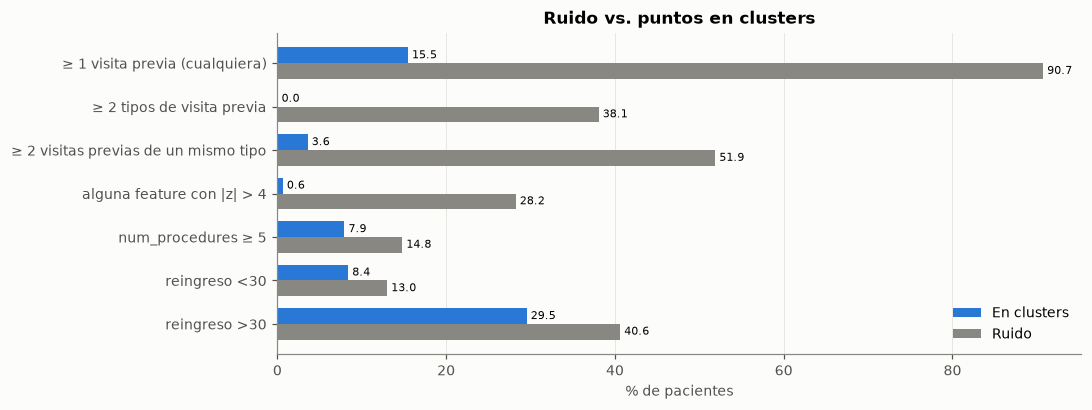

In [16]:
s['es_ruido'] = s['cluster'] == -1
s['n_tipos_visita'] = s[['prev_hosp', 'prev_urg', 'prev_amb']].sum(axis=1)
s['extremo_z4'] = (np.abs(X) > 4).any(axis=1)
s['r30'] = s['readmitted'].eq('<30'); s['r_mas30'] = s['readmitted'].eq('>30')
comp_ruido = s.groupby('es_ruido')[PERFIL].mean().T
comp_ruido.columns = ['En clusters', 'Ruido']
comp_ruido['Ruido / clusters'] = comp_ruido['Ruido'] / comp_ruido['En clusters']
display(comp_ruido.round(2))

indic = {
    '≥ 1 visita previa (cualquiera)': s['n_tipos_visita'] > 0,
    '≥ 2 tipos de visita previa': s['n_tipos_visita'] >= 2,
    '≥ 2 visitas previas de un mismo tipo': (s[['number_inpatient', 'number_emergency', 'number_outpatient']] >= 2).any(axis=1),
    'alguna feature con |z| > 4': s['extremo_z4'],
    'num_procedures ≥ 5': s['num_procedures'] >= 5,
    'reingreso <30': s['r30'],
    'reingreso >30': s['r_mas30'],
}
tabla_ind = pd.DataFrame({k: v.groupby(s['es_ruido']).mean() * 100 for k, v in indic.items()}).T
tabla_ind.columns = ['En clusters (%)', 'Ruido (%)']
display(tabla_ind.round(1))

fig, ax = plt.subplots(figsize=(10, 3.8))
y = np.arange(len(tabla_ind))
ax.barh(y - 0.18, tabla_ind['En clusters (%)'], height=0.36, color=C[0], label='En clusters')
ax.barh(y + 0.18, tabla_ind['Ruido (%)'], height=0.36, color=MUTED, label='Ruido')
for yy, v1, v2 in zip(y, tabla_ind['En clusters (%)'], tabla_ind['Ruido (%)']):
    ax.text(v1 + 0.5, yy - 0.18, f'{v1:.1f}', va='center', fontsize=7.5)
    ax.text(v2 + 0.5, yy + 0.18, f'{v2:.1f}', va='center', fontsize=7.5)
ax.set_yticks(y); ax.set_yticklabels(tabla_ind.index); ax.invert_yaxis(); ax.grid(axis='y', visible=False)
ax.set_xlabel('% de pacientes'); ax.set_title('Ruido vs. puntos en clusters'); ax.legend(frameon=False, loc='lower right')
plt.tight_layout(); plt.show()

**¿Quiénes son el ruido?**
- El 90.7 % del ruido tiene al menos una visita previa (vs. 15.5 % de los puntos en clusters). El 38 % combina **dos o más tipos** de visita (en los clusters: 0 %) y el 52 % tiene **2 o más visitas** de un mismo tipo. En promedio tienen 11–24 veces más visitas previas que los puntos en clusters.
- El 28 % tiene alguna feature extrema (|z| > 4), frente a 0.6 % en los clusters.
- Sus hospitalizaciones son más intensas: +35 % días, +30 % medicamentos, +48 % procedimientos.
- **Reingresan más:** 13.0 % `<30` y 40.6 % `>30`, frente a 8.4 % y 29.5 % de los puntos en clusters.

En resumen, el ruido es el grupo de **pacientes con uso intensivo y variado del sistema de salud**: pocos para formar una zona densa propia, pero clínicamente el grupo más interesante. El ruido de DBSCAN aquí no es “basura”, es la cola de alto riesgo.

## 7. Asignar el resto de filas y comprobar estabilidad

DBSCAN no tiene `predict`. Una regla simple y coherente con el algoritmo: una fila nueva pertenece al cluster de su **punto núcleo más cercano** si está a distancia ≤ `eps` de él (sería un punto frontera); si no, es ruido. Lo aplicamos a las ~50 000 filas que no estaban en la muestra. Si la estructura es real, las proporciones deberían parecerse a las de la muestra.

In [17]:
nucleos = X[modelo.core_sample_indices_]
lab_nucleos = lab[modelo.core_sample_indices_]
resto = np.setdiff1d(np.arange(len(d)), idx)
dist, j = NearestNeighbors(n_neighbors=1).fit(nucleos).kneighbors(Z_all[resto])
lab_resto = np.where(dist[:, 0] <= EPS_F, lab_nucleos[j[:, 0]], -1)

d['cluster'] = -1
d.loc[idx, 'cluster'] = lab
d.loc[resto, 'cluster'] = lab_resto
d['grupo'] = d['cluster'].map(NOMBRES)
prop = pd.DataFrame({'muestra 20k (%)': s['grupo'].value_counts(normalize=True) * 100,
                     'resto asignado (%)': pd.Series(lab_resto).map(NOMBRES).value_counts(normalize=True) * 100}).loc[orden_grupos]
display(prop.round(1))

ct_all = pd.crosstab(d['grupo'], d['readmitted']).loc[orden_grupos, TARGET_ORDER]
tabla_all = (ct_all.div(ct_all.sum(axis=1), axis=0) * 100).round(1).rename(columns=lambda c: f'% {c}')
tabla_all.insert(0, 'n', ct_all.sum(axis=1))
print('Reingreso por cluster en las 69 987 filas:')
display(tabla_all)

,muestra 20k (%),resto asignado (%)
C0 · Sin visitas previas,72.3,72.7
C1 · Consulta amb. previa,6.2,5.9
C2 · Hosp. previa,5.1,5.1
C3 · Urgencias previas,2.0,1.9
Ruido (-1),14.5,14.5


Reingreso por cluster en las 69 987 filas:


readmitted,n,% <30,% >30,% NO
grupo,,,,
C0 · Sin visitas previas,50793,7.9,28.2,63.9
C1 · Consulta amb. previa,4164,8.9,38.9,52.2
C2 · Hosp. previa,3564,14.2,43.1,42.7
C3 · Urgencias previas,1330,9.0,39.5,51.4
Ruido (-1),10136,12.4,41.8,45.8


Las ~50 000 filas no muestreadas se reparten casi igual que la muestra (diferencias ≤ 0.4 puntos) y las tasas de reingreso por cluster en las 69 987 filas se mantienen (C2 hosp. previa 14.2 % `<30`, ruido 12.4 %, C0 7.9 %). La partición es reproducible fuera de la muestra.

**Robustez.** Repetimos la configuración final (a) con otra muestra aleatoria (`random_state=7`), (b) con un jitter N(0, 0.05) sobre las features estandarizadas y (c) con `eps` vecinos y `min_samples = 40`. Para cada caso vemos el n° de clusters relevantes, el % de ruido y si los clusters siguen correspondiendo a los mismos tipos de visita previa.

In [18]:
def resumen(Xsp, datos, eps, ms, nombre):
    lab_ = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1).fit_predict(Xsp)
    dd = datos.assign(cl=lab_)
    tam_ = dd[dd.cl >= 0].cl.value_counts()
    grandes = tam_[tam_ >= 0.01 * len(dd)].index
    desc = []
    for k in grandes:
        g = dd[dd.cl == k]
        partes = [n for col, n in [('number_inpatient', 'hosp'), ('number_emergency', 'urg'), ('number_outpatient', 'amb')] if (g[col] > 0).mean() > 0.5]
        desc.append(f"{'+'.join(partes) or 'sin visitas'} {len(g)/len(dd)*100:.0f}%")
    return dict(escenario=nombre, eps=eps, min_samples=ms, n_clusters=int(dd.cl.max() + 1), n_clusters_1pct=len(grandes),
                pct_ruido=round((lab_ == -1).mean() * 100, 1), clusters_relevantes=' | '.join(desc))

idx7 = d.sample(N_SAMPLE, random_state=7).index.to_numpy()
X_jit = X + np.random.default_rng(SEED).normal(0, 0.05, X.shape)
rob = [resumen(X, s, EPS_F, MS_F, 'Final (muestra 42)'),
       resumen(Z_all[idx7], d.loc[idx7].reset_index(drop=True), EPS_F, MS_F, 'Otra muestra (seed 7)'),
       resumen(X_jit, s, EPS_F, MS_F, 'Con jitter 0.05'),
       resumen(X, s, 1.25, MS_F, 'eps un paso abajo'),
       resumen(X, s, 1.75, MS_F, 'eps un paso arriba'),
       resumen(X, s, 2.0, MS_F, 'eps = 2.0'),
       resumen(X, s, EPS_F, 40, 'min_samples = 40')]
with pd.option_context('display.max_colwidth', 200):
    display(pd.DataFrame(rob))

,escenario,eps,min_samples,n_clusters,n_clusters_1pct,pct_ruido,clusters_relevantes
0,Final (muestra 42),1.50,20,4,4,14.5,sin visitas 72% | amb 6% | hosp 5% | urg 2%
1,Otra muestra (seed 7),1.50,20,4,4,14.2,sin visitas 73% | amb 6% | hosp 5% | urg 2%
2,Con jitter 0.05,1.50,20,4,4,14.8,sin visitas 72% | amb 6% | hosp 5% | urg 2%
3,eps un paso abajo,1.25,20,4,3,26.8,sin visitas 67% | amb 3% | hosp 2%
4,eps un paso arriba,1.75,20,8,4,8.0,sin visitas 73% | amb 8% | hosp 7% | urg 3%
5,eps = 2.0,2.00,20,4,3,4.5,sin visitas 82% | hosp 9% | urg 4%
6,min_samples = 40,1.50,40,4,4,19.4,sin visitas 71% | amb 4% | hosp 4% | urg 1%


- Otra muestra y el jitter dan **exactamente la misma estructura** (4 clusters, 14–15 % de ruido, mismas proporciones): el resultado no depende de la muestra ni de los empates de la grilla.
- Mover `eps` o `min_samples` cambia sobre todo el % de ruido; los clusters siguen siendo las mismas capas de visitas previas. Con `eps` = 1.25 el cluster de urgencias se disuelve en ruido; con `eps` = 2.0 el de consultas ambulatorias se funde con el grande.

## 8. Resumen de la primera versión

**Configuración final:** 10 features `FEAT` estandarizadas, muestra de 20 000 pacientes, `eps = 1.5`, `min_samples = 20` → **4 clusters + 14.5 % de ruido**, silhouette = 0.17 (sin ruido), Davies-Bouldin = 1.74.

| Grupo | % muestra | Qué lo define | % `<30` | % `>30` |
|---|---|---|---|---|
| C0 · Sin visitas previas | 72.3 | 0 visitas previas de ningún tipo | 7.9 | 27.5 |
| C1 · Consulta amb. previa | 6.2 | solo consultas ambulatorias previas | 9.7 | 38.5 |
| C2 · Hosp. previa | 5.1 | solo hospitalizaciones previas | 13.5 | 43.9 |
| C3 · Urgencias previas | 2.0 | solo urgencias previas | 8.0 | 39.2 |
| Ruido (-1) | 14.5 | combinaciones/repeticiones de visitas, estancias más intensas | 13.0 | 40.6 |

**Lo que aprendimos:**
1. **DBSCAN no encuentra grupos clínicos “naturales”.** La intensidad de la hospitalización (días, medicamentos, laboratorios, procedimientos, diagnósticos) es un **continuo**: en ese subespacio y en PCA solo aparece un cluster gigante, o muchos grupitos con 25–80 % de ruido y silhouette ≤ 0.09. Esto confirma la expectativa del EDA.
2. **Los clusters que sí aparecen son “capas” creadas por las variables de visitas previas**, que son discretas y cero-infladas: el salto de 0 a 1 visita deja un hueco de baja densidad. Es una estructura real y muy estable (igual con otra muestra, con jitter y al asignar las 50 000 filas restantes), pero **se podría obtener con una regla simple** (`number_inpatient > 0`, etc.). DBSCAN la redescubre; no agrega información nueva.
3. **El ruido es lo más interesante:** 91 % tiene alguna visita previa, 38 % combina varios tipos, 28 % tiene valores extremos, y reingresa más (13.0 % `<30` vs 8.4 % en los clusters). En este dataset, “ruido” = pacientes de uso intensivo del sistema, no errores.
4. **Relación con `readmitted`:** significativa pero débil (V de Cramér = 0.09). El orden de riesgo es C2 hosp. previa ≈ ruido > C1 ≈ C3 > C0, coherente con que `number_inpatient` fue la mejor predictora del EDA.
5. **Las métricas internas engañan si se miran solas:** el mejor silhouette (0.29) está en `eps = 3`, que es casi un solo cluster; y con `eps = 0.5` el silhouette 0.32 viene con 98.5 % de ruido. Siempre leerlas junto al % de ruido y al tamaño del cluster mayor.

**Limitaciones:**
- Se trabajó sobre una muestra de 20 000 filas (el resto se asignó por núcleo más cercano, lo que es una aproximación: no recalcula la densidad).
- `eps` es un único radio para todo el espacio; si hubiera regiones de densidades distintas, un solo `eps` no las captaría.
- La distancia euclidiana sobre variables discretas y cero-infladas favorece las “capas”. Si se quisiera buscar tipos de hospitalización habría que excluir las visitas previas (lo probamos: no hay estructura).

**Para los siguientes modelos:** para KNN, las banderas de visitas previas (o el propio cluster/ruido) resumen la parte útil de esta estructura; para GMM, conviene modelar solo las variables continuas de intensidad o tratar las visitas previas como banderas, porque de lo contrario las componentes gaussianas también se dedicarán a las capas de ceros.

## 9. Revisión crítica: ¿los clusters son reales?

La primera versión tiene tres problemas que detectamos al revisar la literatura metodológica:

1. **Silhouette y Davies-Bouldin no sirven para DBSCAN.** La documentación de scikit-learn advierte que ambos índices son más altos para clusters **convexos** (redondos) que para clusters basados en densidad. Hay que usar una métrica pensada para densidad: **DBCV** (*Density-Based Clustering Validation*, Moulavi et al., 2014).
2. **Los clusters coinciden con una regla trivial:** “qué tipo de visita previa tuvo el paciente” (pureza del 100 %, sección 5). Las visitas previas son casi binarias y dominan la distancia. Schubert et al. (2017) advierten además que un cluster que contiene a la mayoría de los datos (aquí el 72 %) es síntoma de un `eps` demasiado grande.
3. **La estabilidad no se midió por cluster.** Hennig (2007) propone medir, con re-muestreo bootstrap, qué tan parecido es cada cluster a sí mismo en otras muestras (índice de Jaccard). Criterio de su paquete `fpc`: **≥ 0.75 estable, ≥ 0.85 muy estable, < 0.6 no confiable**.

Plan de esta sección, siempre con **DBSCAN**:
- 9.1 Programar y **validar** las herramientas (DBCV, estabilidad de Jaccard, intervalos de confianza de Wilson).
- 9.2 Evaluar la primera versión con DBCV y estabilidad.
- 9.3 Repetir DBSCAN **sin las visitas previas**.
- 9.4 **Prueba del jitter:** ¿los clusters sobreviven a un ruido que no cambia ningún dato?
- 9.5 **Validación externa:** ¿el ruido de DBSCAN sirve para detectar pacientes de riesgo mejor que una regla simple?

### 9.1 Herramientas de validación

**DBCV** compara, para cada cluster, su zona **menos densa por dentro** con la zona **más densa que lo separa de otro cluster** (usando la *distancia de alcanzabilidad mutua*, que tiene en cuenta la densidad local de cada punto). Va de −1 a +1: **+1 = clusters densos y bien separados; 0 = estructura ambigua; negativo = los “clusters” están menos separados de lo que están cohesionados**. El ruido cuenta en el total, así que declarar mucho ruido penaliza. scikit-learn no lo trae, así que lo programamos siguiendo el paper; su cálculo usa todas las distancias entre pares, así que lo aplicamos sobre una sub-muestra de 4 000 pacientes.

In [19]:
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import pdist, squareform
INK = '#52514e'

def dbcv(X, labels, dist_min=1e-3):
    # Density-Based Clustering Validation (Moulavi et al., 2014). Ruido = -1. Rango [-1, 1], mayor es mejor.
    labels = np.asarray(labels).copy()
    vc = {c: (labels == c).sum() for c in np.unique(labels)}
    labels[np.isin(labels, [c for c, k in vc.items() if k < 3])] = -1   # clusters con < 3 puntos en la muestra -> ruido
    clusters = [c for c in np.unique(labels) if c != -1]
    if len(clusters) < 2:
        return np.nan
    dim, n_total = X.shape[1], len(labels)
    D = np.maximum(squareform(pdist(X)), dist_min)
    info = {}
    for c in clusters:
        idx_c = np.where(labels == c)[0]
        Dc = D[np.ix_(idx_c, idx_c)]
        with np.errstate(over='ignore'):
            inv = (1.0 / Dc) ** dim
        np.fill_diagonal(inv, 0.0)
        core = (inv.sum(axis=1) / (len(idx_c) - 1)) ** (-1.0 / dim)          # all-points core distance
        mrd = np.maximum(np.maximum(core[:, None], core[None, :]), Dc)        # alcanzabilidad mutua
        np.fill_diagonal(mrd, 0.0)
        mst = minimum_spanning_tree(mrd).toarray(); mst = np.maximum(mst, mst.T)
        internos = np.where((mst > 0).sum(axis=1) > 1)[0]
        if len(internos) < 2:
            internos = np.arange(len(idx_c))
        dsc = mst[np.ix_(internos, internos)].max()                           # zona menos densa dentro del cluster
        info[c] = dict(idx=idx_c[internos], core=core[internos], dsc=dsc if dsc > 0 else mst.max(), n=len(idx_c))
    total = 0.0
    for c in clusters:
        dspc = min(np.maximum(np.maximum(info[c]['core'][:, None], info[o]['core'][None, :]),
                              D[np.ix_(info[c]['idx'], info[o]['idx'])]).min() for o in clusters if o != c)
        total += info[c]['n'] / n_total * (dspc - info[c]['dsc']) / max(dspc, info[c]['dsc'])
    return total

def estabilidad_jaccard(X, labels, ajustar, B=10, seed=0):
    # Inspirado en Hennig (2007): Jaccard medio de cada cluster con su cluster más parecido en re-muestras.
    # Se usan los puntos únicos de cada muestra bootstrap (~63 % de los datos, sin duplicados), es decir,
    # es una variante de submuestreo; con eps fijo, la densidad baja un poco. B = 10 por costo de cómputo.
    rng_ = np.random.default_rng(seed)
    labels = np.asarray(labels)
    clusters = [c for c in np.unique(labels) if c != -1]
    res = {c: [] for c in clusters}
    for _ in range(B):
        ib = np.unique(rng_.integers(0, len(labels), len(labels)))
        lb, orig = np.asarray(ajustar(X[ib])), labels[ib]
        for c in clusters:
            A = orig == c
            res[c].append(max([(A & (lb == k)).sum() / (A | (lb == k)).sum() for k in np.unique(lb) if k != -1] or [0]))
    return {c: float(np.mean(v)) for c, v in res.items()}

def wilson(k, n, z=1.96):
    # intervalo de confianza 95 % para una proporción (Wilson)
    p, den = k / n, 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / den
    m = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return centro - m, centro + m

SUB = np.random.default_rng(0).choice(len(X), 4000, replace=False)   # sub-muestra para DBCV

**¿La implementación de DBCV mide lo que dice medir?** La probamos en un caso de juguete donde sabemos la respuesta: dos “lunas” entrelazadas. DBSCAN las separa bien; como etiquetado incorrecto usamos un corte recto por la mitad (lo que haría un método de clusters redondos); y como control, etiquetas al azar.

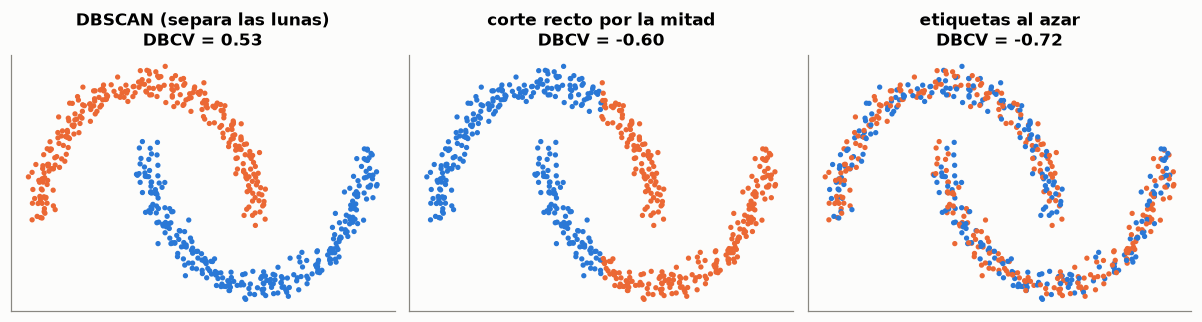

In [20]:
from sklearn.datasets import make_moons
Xm, _ = make_moons(600, noise=0.06, random_state=0)
lab_bien = DBSCAN(eps=0.2, min_samples=5).fit_predict(Xm)
lab_corte = (Xm[:, 0] > 0.5).astype(int)
lab_azar = np.random.default_rng(0).integers(0, 2, len(Xm))
prueba = pd.Series({'DBSCAN (separa las lunas)': dbcv(Xm, lab_bien),
                    'corte recto por la mitad': dbcv(Xm, lab_corte),
                    'etiquetas al azar': dbcv(Xm, lab_azar)}, name='DBCV')

fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, lab_, tit in zip(axes, [lab_bien, lab_corte, lab_azar], prueba.index):
    ax.scatter(Xm[:, 0], Xm[:, 1], c=[C[0] if l == 0 else C[1] for l in lab_], s=6)
    ax.set_title(f'{tit}\nDBCV = {prueba[tit]:.2f}'); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

DBCV se comporta como se espera: **positivo (+0.53) cuando los clusters siguen la densidad**, muy negativo cuando se corta una zona densa por la mitad y también con etiquetas al azar. Con esto podemos usarlo en los datos reales.

### 9.2 La primera versión, evaluada con DBCV y estabilidad
Comparamos la configuración de la sección 5 (`eps = 1.5`, `min_samples = 20`, 10 variables) con la **regla trivial** “tipo de visita previa” (ninguna / solo ambulatoria / solo hospitalización / solo urgencias; las combinaciones quedan como “ruido”).

In [21]:
lab_v1 = DBSCAN(eps=1.5, min_samples=20, n_jobs=-1).fit_predict(X)
vis = s[['number_outpatient', 'number_emergency', 'number_inpatient']] > 0
regla = np.select([~vis.any(axis=1),
                   vis.number_outpatient & ~vis.number_emergency & ~vis.number_inpatient,
                   vis.number_inpatient & ~vis.number_outpatient & ~vis.number_emergency,
                   vis.number_emergency & ~vis.number_outpatient & ~vis.number_inpatient], [0, 1, 2, 3], -1)

t = time.time()
est_v1 = estabilidad_jaccard(X, lab_v1, lambda Z: DBSCAN(eps=1.5, min_samples=20, n_jobs=-1).fit_predict(Z))
tab_v1 = pd.DataFrame({
    '% muestra': pd.Series(lab_v1).value_counts(normalize=True).sort_index() * 100,
    'estabilidad Jaccard': pd.Series(est_v1),
    'pureza tipo de visita': pd.Series({c: pd.Series(regla[lab_v1 == c]).value_counts(normalize=True).iloc[0] for c in set(lab_v1) - {-1}}),
}).round(3)
print(f'DBCV primera versión: {dbcv(X[SUB], lab_v1[SUB]):.3f}   |   DBCV regla trivial: {dbcv(X[SUB], regla[SUB]):.3f}   ({time.time() - t:.0f} s)')
tab_v1

DBCV primera versión: -0.301   |   DBCV regla trivial: -0.343   (14 s)


,% muestra,estabilidad Jaccard,pureza tipo de visita
-1,14.505,NaN,NaN
0,72.280,0.986,1.0
1,5.055,0.785,1.0
2,6.155,0.787,1.0
3,2.005,0.774,1.0


- **DBCV = −0.30:** negativo. Los clusters de la primera versión están *menos separados de lo que están cohesionados*: no son zonas densas separadas por huecos. La regla trivial obtiene casi lo mismo (−0.34), es decir, **DBSCAN no está encontrando nada mejor que la regla**.
- **Pureza del 100 %:** cada cluster es exactamente un tipo de visita previa.
- **Estabilidad:** el cluster grande (sin visitas previas) tiene Jaccard 0.99 y los otros tres 0.77–0.79, todos “estables” según el criterio de Hennig. Pero estable no significa útil: esas “capas” son reales y se reproducen en cada re-muestra porque dependen de cómo están codificadas las visitas previas, y **las reproduce una regla trivial sin necesidad de un modelo**. En la sección 9.4 veremos un caso más extremo: clusters igual de estables que son directamente un artefacto.

### 9.3 DBSCAN sin las visitas previas

Sacamos las 3 variables de visitas previas del espacio de clustering (las usaremos solo para **validar** después) y nos quedamos con las 7 variables de la hospitalización actual: `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses`, `age_num`, `n_meds_activos`. Con 7 dimensiones, la regla `min_samples = 2 × dim` da **14** (Schubert et al., 2017), y el gráfico k-distancia usa k = 13.

Grilla en 16 s


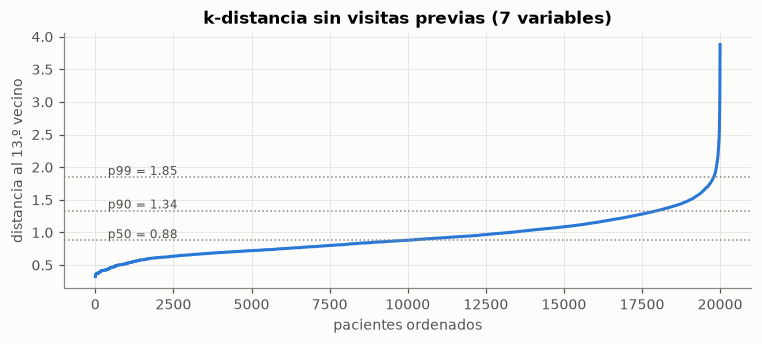

,eps,min_samples,clusters (≥1 %),% ruido,% cluster mayor,DBCV
0,0.6,14,6,82.005,4.205,-0.052
1,0.6,30,3,93.035,1.615,-0.005
2,0.8,14,4,42.000,29.615,-0.260
3,0.8,30,3,59.255,22.440,-0.119
4,1.0,14,4,16.250,39.780,-0.449
5,1.0,30,4,27.900,35.670,-0.331
6,1.2,14,1,6.170,93.730,-0.276
7,1.2,30,1,11.145,88.855,NaN
8,1.5,14,1,1.050,98.950,NaN
9,1.5,30,1,1.865,98.135,NaN


In [22]:
F7 = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'age_num', 'n_meds_activos']
X7 = StandardScaler().fit(d[F7]).transform(s[F7])
kd7 = np.sort(NearestNeighbors(n_neighbors=14).fit(X7).kneighbors(X7)[0][:, -1])

filas = []
t = time.time()
for eps in [0.6, 0.8, 1.0, 1.2, 1.5]:
    for ms in [14, 30]:
        lab_ = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1).fit_predict(X7)
        tam = pd.Series(lab_[lab_ >= 0]).value_counts() / len(lab_)
        filas.append({'eps': eps, 'min_samples': ms, 'clusters (≥1 %)': int((tam >= 0.01).sum()),
                      '% ruido': (lab_ == -1).mean() * 100, '% cluster mayor': tam.max() * 100 if len(tam) else 0,
                      'DBCV': dbcv(X7[SUB], lab_[SUB])})
grid7 = pd.DataFrame(filas)
print(f'Grilla en {time.time() - t:.0f} s')

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(kd7, color=C[0], lw=2)
for p_ in [50, 90, 99]:
    ax.axhline(np.percentile(kd7, p_), color=MUTED, ls=':', lw=1)
    ax.text(len(kd7) * 0.02, np.percentile(kd7, p_) + 0.03, f'p{p_} = {np.percentile(kd7, p_):.2f}', color=INK, fontsize=8)
ax.set_xlabel('pacientes ordenados'); ax.set_ylabel('distancia al 13.º vecino')
ax.set_title('k-distancia sin visitas previas (7 variables)')
plt.tight_layout(); plt.show()
grid7.round(3)

- **La curva k-distancia sube de forma gradual**, sin un codo marcado: la densidad cambia de manera continua.
- **DBCV es negativo en todas las configuraciones** (de −0.005 a −0.45). No hay ninguna combinación de `eps` y `min_samples` que produzca clusters densos y separados.
- El patrón es el típico de datos **sin estructura de clusters**: con `eps` ≥ 1.2 todo es un solo cluster (89–99 % de los pacientes); con `eps` ≤ 0.8 la mayoría es ruido (42–93 %). En la zona intermedia (`eps` = 1.0) aparecen 4 clusters, justo con el **peor DBCV** (−0.45). La sección siguiente muestra qué son.

### 9.4 Prueba del jitter: ¿los clusters sobreviven?

Tomamos la configuración `eps = 1.0`, `min_samples = 14` (4 clusters, 16 % de ruido) y miramos **qué hay dentro de cada cluster**. Después hacemos la prueba decisiva: a cada variable entera le sumamos un ruido uniforme de ±0.5 (±5 en la edad). Ese ruido **no cambia ningún dato** (redondeando se recupera el valor original), pero rompe la grilla de valores enteros. **Si los clusters fueran grupos reales de pacientes, deberían sobrevivir; si desaparecen, eran un artefacto de la discretez.**

In [23]:
EPS_P, MS_P = 1.0, 14
lab7 = DBSCAN(eps=EPS_P, min_samples=MS_P, n_jobs=-1).fit_predict(X7)

jit = s[F7].astype(float).copy()
rj = np.random.default_rng(1)
for c in F7:
    jit[c] += rj.uniform(-0.5, 0.5, len(jit)) * (10 if c == 'age_num' else 1)
X7j = StandardScaler().fit_transform(jit)
lab7j = DBSCAN(eps=EPS_P, min_samples=MS_P, n_jobs=-1).fit_predict(X7j)

t = time.time()
est7 = estabilidad_jaccard(X7, lab7, lambda Z: DBSCAN(eps=EPS_P, min_samples=MS_P, n_jobs=-1).fit_predict(Z))
grandes = [c for c, k in pd.Series(lab7).value_counts().items() if c != -1 and k / len(lab7) >= 0.01]
tab7 = pd.DataFrame({
    '% muestra': [(lab7 == c).mean() * 100 for c in grandes],
    'n_meds_activos más frecuente': [int(s.n_meds_activos[lab7 == c].mode()[0]) for c in grandes],
    '% con ese valor (pureza)': [s.n_meds_activos[lab7 == c].value_counts(normalize=True).iloc[0] * 100 for c in grandes],
    'estabilidad Jaccard': [est7[c] for c in grandes],
}, index=[f'cluster {c}' for c in grandes]).round(2)
print(f'Estabilidad calculada en {time.time() - t:.0f} s')
display(tab7)

def resumen_lab(lab_, Xm):
    tam = pd.Series(lab_[lab_ >= 0]).value_counts() / len(lab_)
    return {'clusters (≥1 %)': int((tam >= 0.01).sum()), '% ruido': (lab_ == -1).mean() * 100,
            '% cluster mayor': tam.max() * 100 if len(tam) else 0, 'DBCV': dbcv(Xm[SUB], lab_[SUB])}
pd.DataFrame({'datos originales (enteros)': resumen_lab(lab7, X7), 'con jitter (mismos datos)': resumen_lab(lab7j, X7j)}).T.round(3)

Estabilidad calculada en 3 s


,% muestra,n_meds_activos más frecuente,% con ese valor (pureza),estabilidad Jaccard
cluster 0,39.78,1,100.0,0.94
cluster 1,20.54,0,100.0,0.89
cluster 2,18.08,2,100.0,0.91
cluster 3,5.12,3,100.0,0.85


,clusters (≥1 %),% ruido,% cluster mayor,DBCV
datos originales (enteros),4.0,16.250,39.78,-0.449
con jitter (mismos datos),1.0,17.695,82.13,-0.344


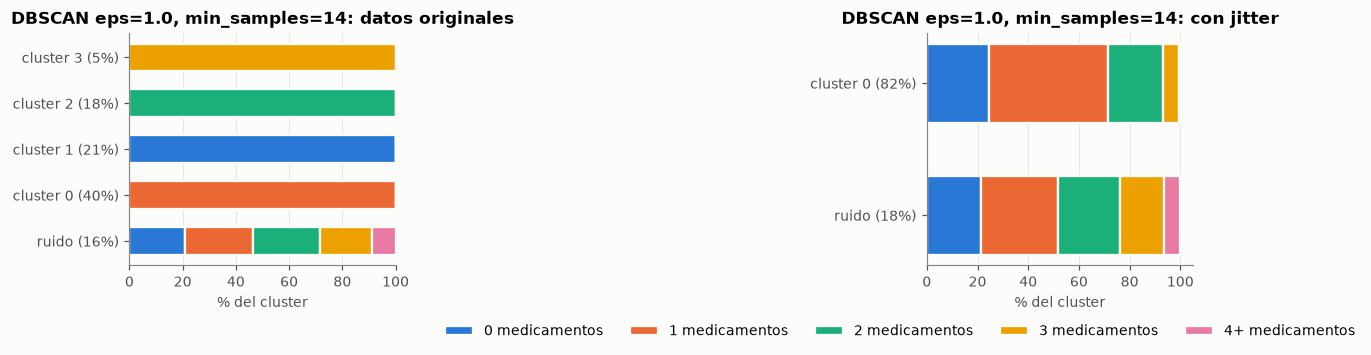

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, lab_, tit in zip(axes, [lab7, lab7j], ['datos originales', 'con jitter']):
    ct = pd.crosstab(pd.Series(lab_, name='cluster'), s['n_meds_activos'].clip(upper=4).rename('n_meds'), normalize='index') * 100
    tam = pd.Series(lab_).value_counts(normalize=True)
    ct = ct.loc[[c for c in ct.index if c == -1 or tam[c] >= 0.01]]
    izq = np.zeros(len(ct))
    for j, v in enumerate(ct.columns):
        ax.barh([('ruido' if c == -1 else f'cluster {c}') + f' ({tam[c]:.0%})' for c in ct.index], ct[v], left=izq,
                color=C[j], label=f'{v}{"+" if v == 4 else ""} medicamentos', height=0.6, edgecolor='#fcfcfb', linewidth=1.5)
        izq += ct[v].values
    ax.set_title(f'DBSCAN eps={EPS_P}, min_samples={MS_P}: {tit}'); ax.set_xlabel('% del cluster'); ax.grid(axis='y', visible=False)
axes[1].legend(frameon=False, loc='upper center', bbox_to_anchor=(-0.1, -0.2), ncol=5)
plt.tight_layout(); plt.show()

- **Los 4 clusters son exactamente “0, 1, 2 y 3 medicamentos para la diabetes”** (`n_meds_activos`), con pureza del 100 %. Además son muy estables (Jaccard 0.85–0.94).
- **Con jitter, se funden en un solo cluster** (82 % de los pacientes) más ruido, que mezcla todos los valores de `n_meds_activos`. Los datos son los mismos; solo se rompió la grilla de enteros.
- **Por qué pasa:** entre “1 medicamento” y “2 medicamentos” no existe ningún paciente intermedio. Tras estandarizar, ese salto deja un “hueco” de densidad cero que DBSCAN interpreta como separación entre clusters. **Es un artefacto de que la variable es discreta, no un grupo de pacientes.**
- **Conclusión:** en las variables de la hospitalización actual **no hay clusters por densidad**. Es lo mismo que pasó en la primera versión con las visitas previas: DBSCAN encuentra los escalones de la variable discreta más “gruesa” que haya en el espacio.

### 9.5 Validación externa: ¿el ruido detecta pacientes de riesgo?

Si no hay clusters reales, lo que queda de DBSCAN es el **ruido**: pacientes que no están en ninguna zona densa. En la primera versión reingresaban más (13.0 % contra 8.4 %). Para saber si DBSCAN aporta algo, comparamos ese ruido con **reglas simples** que cualquiera podría aplicar sin un modelo, usando la tasa de reingreso `<30` con su **intervalo de confianza del 95 %** (Wilson), el **riesgo relativo** (tasa del grupo marcado / tasa del resto) y qué fracción de todos los reingresos captura cada criterio.

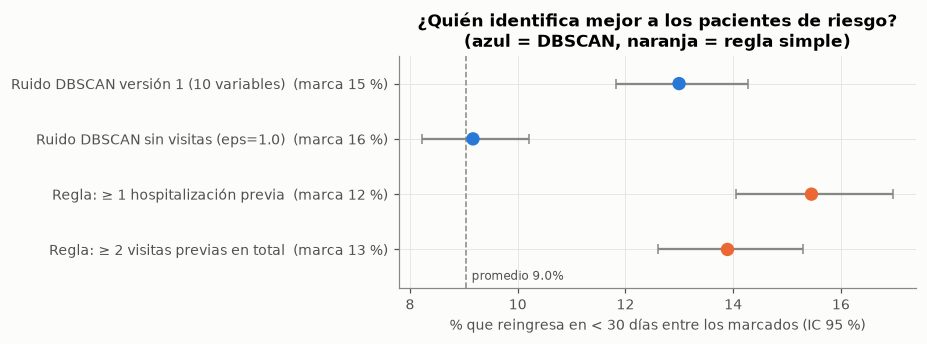

,% pacientes marcados,tasa <30 marcados,IC 2.5 %,IC 97.5 %,tasa <30 resto,riesgo relativo,% de reingresos capturados
criterio,,,,,,,
Ruido DBSCAN versión 1 (10 variables),14.505,0.130,0.118,0.143,0.084,1.552,20.840
Ruido DBSCAN sin visitas (eps=1.0),16.250,0.092,0.082,0.102,0.090,1.016,16.473
Regla: ≥ 1 hospitalización previa,11.875,0.155,0.141,0.170,0.082,1.889,20.287
Regla: ≥ 2 visitas previas en total,12.560,0.139,0.126,0.153,0.083,1.664,19.292


In [25]:
yv = s['readmitted_30'].to_numpy()
visitas = s[['number_outpatient', 'number_emergency', 'number_inpatient']]
criterios = {
    'Ruido DBSCAN versión 1 (10 variables)': lab_v1 == -1,
    f'Ruido DBSCAN sin visitas (eps={EPS_P})': lab7 == -1,
    'Regla: ≥ 1 hospitalización previa': s['number_inpatient'].to_numpy() >= 1,
    'Regla: ≥ 2 visitas previas en total': visitas.sum(axis=1).to_numpy() >= 2,
}
filas = []
for nombre, m in criterios.items():
    lo, hi = wilson(yv[m].sum(), m.sum())
    filas.append({'criterio': nombre, '% pacientes marcados': m.mean() * 100, 'tasa <30 marcados': yv[m].mean(),
                  'IC 2.5 %': lo, 'IC 97.5 %': hi, 'tasa <30 resto': yv[~m].mean(),
                  'riesgo relativo': yv[m].mean() / yv[~m].mean(), '% de reingresos capturados': yv[m].sum() / yv.sum() * 100})
ext = pd.DataFrame(filas).set_index('criterio')

fig, ax = plt.subplots(figsize=(8.5, 3.2))
e = ext.iloc[::-1]
col = [C[1] if 'Regla' in i else C[0] for i in e.index]
ax.errorbar(e['tasa <30 marcados'] * 100, range(len(e)), xerr=[(e['tasa <30 marcados'] - e['IC 2.5 %']) * 100,
            (e['IC 97.5 %'] - e['tasa <30 marcados']) * 100], fmt='none', ecolor=MUTED, capsize=3)
ax.scatter(e['tasa <30 marcados'] * 100, range(len(e)), color=col, s=60, zorder=3)
ax.axvline(yv.mean() * 100, color=MUTED, ls='--', lw=1)
ax.text(yv.mean() * 100 + 0.1, -0.55, f'promedio {yv.mean():.1%}', color=INK, fontsize=8)
ax.set_ylim(-0.7, len(e) - 0.5)
ax.set_yticks(range(len(e)), [f'{i}  (marca {p:.0f} %)' for i, p in zip(e.index, e['% pacientes marcados'])])
ax.set_xlabel('% que reingresa en < 30 días entre los marcados (IC 95 %)')
ax.set_title('¿Quién identifica mejor a los pacientes de riesgo?\n(azul = DBSCAN, naranja = regla simple)')
plt.tight_layout(); plt.show()
ext.round(3)

- **Ruido de la primera versión:** reingresa el **13.0 %** (IC 95 % [11.8, 14.3]) contra 8.4 % del resto, es decir, un riesgo relativo de **1.55**. Marca al 14.5 % de los pacientes y captura el 20.8 % de los reingresos. Hay señal real.
- **Ruido sin visitas previas:** reingresa el 9.2 %, igual que el promedio (riesgo relativo 1.02). **Sin las visitas previas, los atípicos de DBSCAN no dicen nada sobre el reingreso**: toda la señal del ruido venía de las visitas previas.
- **La regla “≥ 1 hospitalización previa” es mejor que el ruido de DBSCAN en todo:** marca a **menos** pacientes (11.9 % contra 14.5 %), su tasa de reingreso es **mayor** (15.5 %, IC [14.1, 17.0]; riesgo relativo **1.89**) y captura prácticamente los mismos reingresos (20.3 % contra 20.8 %).
- **Conclusión:** el ruido de DBSCAN es una versión menos precisa de “el paciente ya había estado hospitalizado”. Como detector de riesgo, DBSCAN no le agrega nada a una regla que se aplica sin modelo.

## 10. Conclusiones

| | Primera versión (secciones 3–8) | Revisión (sección 9) |
|---|---|---|
| Variables | 10, con visitas previas | 7, sin visitas previas (las visitas se usan para validar) |
| Métrica de validación | silhouette 0.17, Davies-Bouldin 1.74 (no aptas para densidad) | **DBCV** (diseñada para densidad), validada con datos de juguete |
| Resultado | 4 clusters + 14.5 % de ruido | DBCV negativo en todas las configuraciones |
| ¿Qué son los clusters? | tipos de visita previa (pureza 100 %; DBCV −0.30, igual que la regla trivial −0.34) | valores de `n_meds_activos` (pureza 100 %); **desaparecen con jitter** |
| Estabilidad (Jaccard) | 0.77–0.99 (capas reales pero triviales) | 0.85–0.94, pero de un artefacto |
| Utilidad del ruido | reingreso 13.0 % [11.8, 14.3], riesgo relativo 1.55 | sin señal (riesgo relativo 1.02) |

1. **Este dataset no tiene clusters por densidad.** Evaluado con la métrica correcta (DBCV), ninguna configuración de DBSCAN produce zonas densas separadas, con o sin visitas previas. Coincide con el EDA (una sola nube en PCA, Hopkins inflado por la discretez) y con la literatura: no encontramos trabajos que hayan hallado fenotipos de pacientes por clustering en este dataset.
2. **Lo que DBSCAN encuentra son los “escalones” de las variables discretas.** Con visitas previas separa “0 visitas” de “≥ 1 visita” por tipo; sin ellas, separa 0, 1, 2 y 3 medicamentos. La **prueba del jitter** lo demuestra: si se rompe la grilla de enteros sin cambiar ningún dato, los clusters desaparecen.
3. **Estable no significa real.** Los clusters de la versión sin visitas previas eran un artefacto de la discretez (desaparecen con jitter) y aun así tenían estabilidad de Jaccard de 0.85 a 0.94. Los de la primera versión son todavía más estables (hasta 0.99), pero equivalen a una regla trivial. La estabilidad solo dice que el resultado se repite, no que corresponda a grupos de pacientes; hay que combinarla con DBCV y con validación externa.
4. **Las métricas internas clásicas engañan con DBSCAN.** Silhouette y Davies-Bouldin favorecen grupos redondos; con ellas la primera versión parecía razonable (silhouette 0.17), con DBCV queda claro que no lo es.
5. **El único producto útil de DBSCAN es el ruido de la primera versión** (pacientes de uso intensivo del sistema, que reingresan un 13 %). Pero una regla simple, “≥ 1 hospitalización previa”, identifica mejor a los pacientes de riesgo: marca a menos pacientes, con un riesgo relativo mayor (1.89 contra 1.55).
6. **Para la presentación:** el valor de DBSCAN en este proyecto es **diagnóstico**. Aplicado con cuidado, muestra que los pacientes forman un continuo y no grupos naturales, y que las segmentaciones que parecen aparecer son artefactos o reglas triviales que dependen de cómo están codificadas las variables. Por eso el enfoque útil para este problema es predictivo (KNN), no de clustering.

**Limitaciones:**
- Se trabajó con una muestra de 20 000 pacientes; DBCV se calculó sobre una sub-muestra de 4 000 (usa todas las distancias entre pares) y la estabilidad con 10 re-muestras (puntos únicos de cada muestra bootstrap, una variante de submuestreo; Hennig recomienda más réplicas).
- DBSCAN usa un solo radio `eps` para todo el espacio; la conclusión se apoya en que DBCV es negativo en toda la grilla, no en una sola configuración.
- La distancia euclidiana sobre variables estandarizadas trata igual a todas las variables; con otras escalas o ponderaciones los escalones que aparecen podrían ser otros, pero seguirían siendo escalones de variables discretas.

In [26]:
print(f'Tiempo total de ejecución del notebook: {(time.time() - T0) / 60:.1f} min')

Tiempo total de ejecución del notebook: 3.8 min
